# Projet ML: Prédiction du CO2 par habitant à partir du profil socio-économique d'un pays

**Objectif du projet** : comprendre comment le profil socio-économique d'un pays (développement, mode de vie, structure de production) permet de prédire ses émissions de CO2 par habitant (`co2_per_capita`).

**Dataset** : *Global Climate & CO2 Anomalies (1990-2024)*, 30 pays, 35 ans, 54 variables (climat, énergie, socio-économie). Source : Kaggle.

**Plan du notebook** :
1. Chargement des données
2. Exploration: comprendre la structure du dataset et les relations entre variables
3. Choix de la variable cible
4. Preprocessing (features, lags, split train/test)
5. Modélisation (régression linéaire vs Random Forest)
6. Optimisation des hyperparamètres (Optuna)
7. Diagnostic (learning curve, feature importance)
8. Prochaines étapes

## 1. Chargement des données

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [71]:
df = pd.read_csv("global_climate_co2_anomalies.csv")   # chemin relatif : fichier à la racine du projet

df.head()

<>:1: SyntaxWarning:

invalid escape sequence '\C'

<>:1: SyntaxWarning:

invalid escape sequence '\C'

C:\Users\julie\AppData\Local\Temp\ipykernel_6864\116365096.py:1: SyntaxWarning:

invalid escape sequence '\C'



,country,iso_code,year,month,continent,income_group,latitude,longitude,latitude_band,climate_zone,...,forest_cover_pct,industrial_share_gdp,agriculture_share_gdp,vehicle_ownership,radiative_forcing,temp_change_from_co2,climate_risk_score,warming_category,renewable_transition_stage,emission_intensity_level
0,Argentina,ARG,1990,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,264.0,2.0,0.29,12.2,Normal,Low,Medium
1,Argentina,ARG,1990,2,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,260.0,2.0,0.29,18.5,Normal,Low,Medium
2,Argentina,ARG,1990,3,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,276.0,2.0,0.29,19.6,Normal,Low,Medium
3,Argentina,ARG,1990,4,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,278.0,2.0,0.29,15.1,Normal,Low,Medium
4,Argentina,ARG,1990,5,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,265.0,2.0,0.29,13.0,Normal,Low,Medium


**Problème découvert en explorant les données** : le CSV contient 12 600 lignes, mais avec 30 pays × 35 ans x12 mois/ans. Mais la plupart des variables (socio-économiques notamment) ne changent qu'une fois par an et sont **répétées à l'identique sur les 12 mois** de chaque année. Les garder créerait un risque de fuite de données (les 12 mois d'une même année pourraient se retrouver éclatés entre train et test). On réduit donc le dataset à une ligne par pays/année. Je choisis la 1er mois de chaque année

In [6]:
# Garder une seule ligne par pays/année au lieu de 12 (voir explication ci-dessus)
df_annual = df.drop_duplicates(subset=['country','year'], keep='first')

In [7]:
df_annual.head()

,country,iso_code,year,month,continent,income_group,latitude,longitude,latitude_band,climate_zone,...,forest_cover_pct,industrial_share_gdp,agriculture_share_gdp,vehicle_ownership,radiative_forcing,temp_change_from_co2,climate_risk_score,warming_category,renewable_transition_stage,emission_intensity_level
0,Argentina,ARG,1990,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,264.0,2.000,0.29,12.2,Normal,Low,Medium
12,Argentina,ARG,1991,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,276.0,2.059,0.27,17.7,Normal,Low,Medium
24,Argentina,ARG,1992,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,278.0,2.118,0.17,10.5,Normal,Low,Medium
36,Argentina,ARG,1993,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,284.0,2.177,0.17,9.3,Normal,Low,Medium
48,Argentina,ARG,1994,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,275.0,2.236,0.22,15.6,Normal,Low,Medium


In [8]:
# Vue d'ensemble des 54 colonnes disponibles
for col in df.columns:
    print(col)

country
iso_code
year
month
continent
income_group
latitude
longitude
latitude_band
climate_zone
temp_anomaly_global
temp_anomaly_land
temp_anomaly_ocean
temp_anomaly_arctic
temp_max
temp_min
co2_emissions
co2_per_capita
co2_per_gdp
cumulative_co2
co2_concentration_ppm
methane_emissions
nitrous_oxide
total_ghg
land_use_change_co2
sea_ice_extent_arctic
sea_ice_extent_antarc
sea_surface_temp_anom
nino34_index
ocean_heat_content
precipitation_anomaly
drought_index_pdsi
spi_3month
primary_energy_twh
share_renewables_pct
share_coal_pct
co2_per_kwh
electricity_demand_twh
renewable_capacity_gw
oil_production
population_millions
gdp_per_capita_usd
population_density
urbanization_rate
forest_cover_pct
industrial_share_gdp
agriculture_share_gdp
vehicle_ownership
radiative_forcing
temp_change_from_co2
climate_risk_score
warming_category
renewable_transition_stage
emission_intensity_level


## 2. Exploration, visualisation

### Population vs émissions totales de CO2

Première question : le volume total d'émissions d'un pays est-il simplement lié à sa taille démographique ?

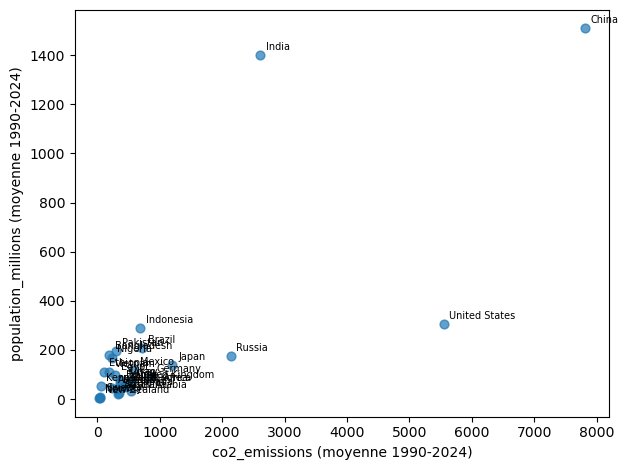

In [9]:
df_by_country = df_annual.groupby('country')[['population_millions','co2_per_capita','co2_emissions']].mean().reset_index()


plt.scatter(df_by_country['co2_emissions'], df_by_country['population_millions'], alpha=0.7, s=40)

for _, row in df_by_country.iterrows():
    plt.annotate(row['country'], (row['co2_emissions'], row['population_millions']),
                 fontsize=(7), xytext=(4,4), textcoords='offset points')

plt.xlabel('co2_emissions (moyenne 1990-2024)')
plt.ylabel('population_millions (moyenne 1990-2024)')
plt.tight_layout()
plt.show()

**Constat** : relation clairement positive — plus un pays est peuplé, plus ses émissions totales sont élevées (Chine et Inde très à l'écart des autres). Logique mathématiquement : `co2_emissions = population × co2_per_capita`, et la population varie sur une bien plus grande échelle (~500x entre le plus petit et le plus grand pays) que le CO2 par habitant (~40x) — c'est donc elle qui domine le total, quasiment par construction.

### Qu'en est-il de `co2_per_capita` (CO2 par habitant) ?

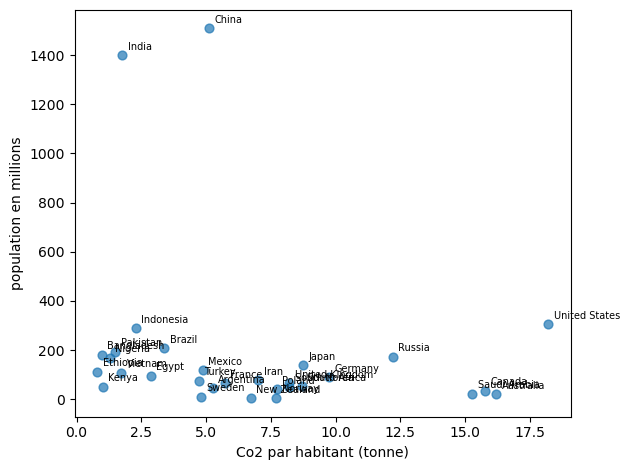

In [81]:
# Un point = un pays : moyenne sur les 35 ans
df_by_country = df_annual.groupby('country')[['population_millions','co2_per_capita']].mean().reset_index()

plt.scatter(df_by_country['co2_per_capita'], df_by_country['population_millions'], alpha=0.7, s=40)

for _, row in df_by_country.iterrows():
    plt.annotate(row['country'], (row['co2_per_capita'],row['population_millions']), fontsize=7, xytext=(4,4), textcoords='offset points')

plt.xlabel('Co2 par habitant (tonne)')
plt.ylabel('population en millions')
plt.tight_layout()
plt.show()

**Constat** : ici, plus de relation nette avec la population — l'Inde (très peuplée) a un `co2_per_capita` faible, alors que des pays peu peuplés comme l'Australie ou le Canada ont un `co2_per_capita` très élevé. Ça confirme que `co2_per_capita` raconte une histoire différente de `co2_emissions` : plutôt liée au développement/mode de vie qu'à la taille du pays.

**Question soulevée** : est-ce que `co2_per_capita` est une simple division `co2_emissions / population_millions`, ou une variable calculée différemment (empreinte carbone individuelle) ? Vérifions.

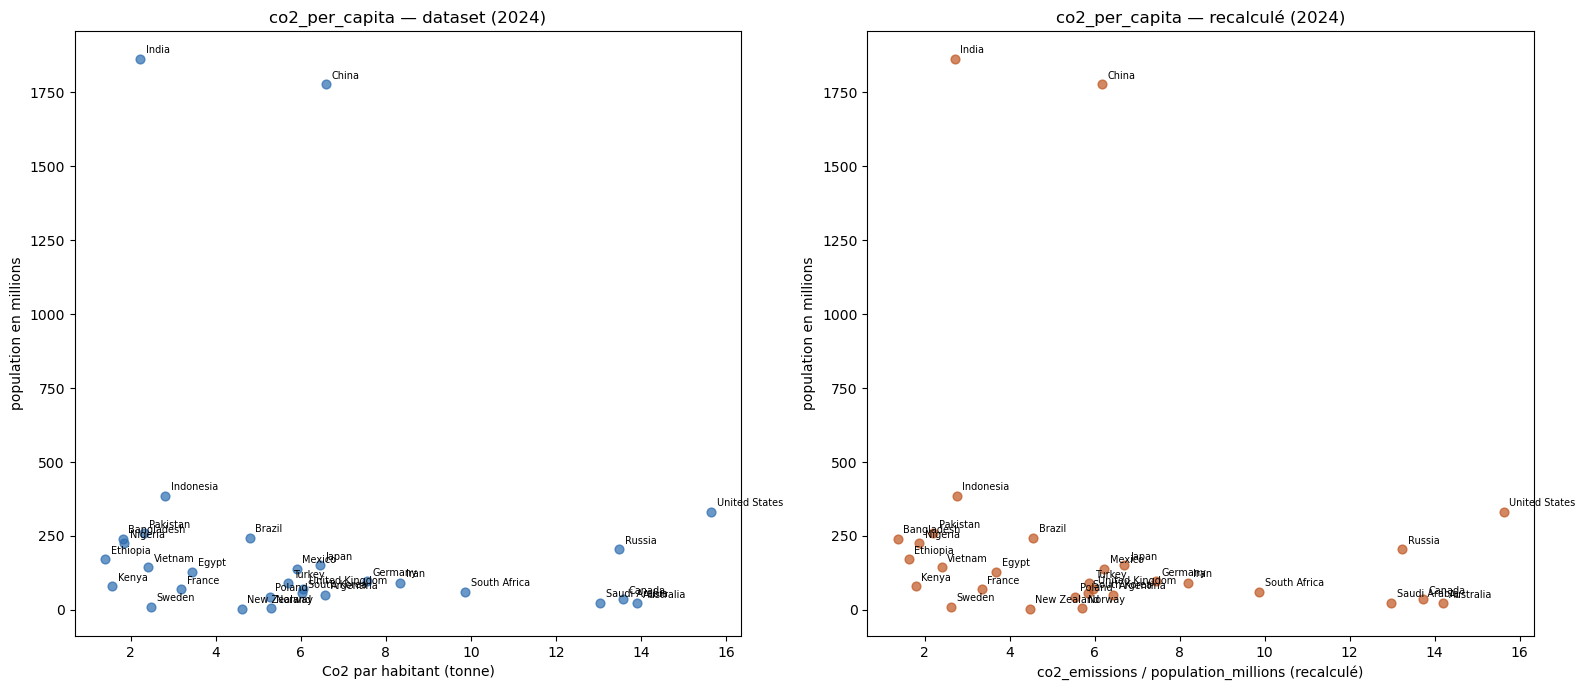

Écart absolu moyen: 0.19218796544860492
Écart absolu max: 0.47999195041455334
Corrélation: 0.9984291896658517


In [80]:
# Dernière année uniquement (2024), 1 point = 1 pays
df_last = df_annual[df_annual['year'] == df_annual['year'].max()].copy()
df_last['co2_pa_calc'] = df_last['co2_emissions'] / df_last['population_millions']

fig, axes = plt.subplots(1, 2, figsize=(16,7))

axes[0].scatter(df_last['co2_per_capita'], df_last['population_millions'], alpha=0.7, s=40, color='#2b6cb0')
for _, row in df_last.iterrows():
    axes[0].annotate(row['country'], (row['co2_per_capita'],row['population_millions']), fontsize=7, xytext=(4,4), textcoords='offset points')
axes[0].set_xlabel('Co2 par habitant (tonne)')
axes[0].set_ylabel('population en millions')
axes[0].set_title(f"co2_per_capita — dataset ({int(df_annual['year'].max())})")

axes[1].scatter(df_last['co2_pa_calc'], df_last['population_millions'],  alpha=0.7, s=40, color='#c05621')
for _, row in df_last.iterrows():
    axes[1].annotate(row['country'], (row['co2_pa_calc'], row['population_millions']), fontsize=7, xytext=(4,4), textcoords='offset points')
axes[1].set_xlabel('co2_emissions / population_millions (recalculé)')
axes[1].set_ylabel('population en millions')
axes[1].set_title(f"co2_per_capita — recalculé ({int(df_annual['year'].max())})")

plt.tight_layout()
plt.show()

diff = (df_last['co2_per_capita'] - df_last['co2_pa_calc']).abs()
print("Écart absolu moyen:", diff.mean())
print("Écart absolu max:", diff.max())
print("Corrélation:", df_last['co2_per_capita'].corr(df_last['co2_pa_calc']))

**Conclusion de cette vérification** : `co2_per_capita` et `co2_emissions / population_millions` sont extrêmement corrélées (>0.998) une fois agrégées par pays. `co2_per_capita` **est bien** dérivée de `co2_emissions`. Ce n'est donc pas une "empreinte carbone individuelle" indépendante : c'est la même information territoriale que `co2_emissions`, juste ramenée par habitant.

### Quelles variables socio-économiques sont liées à `co2_per_capita` et à `co2_emissions` ?

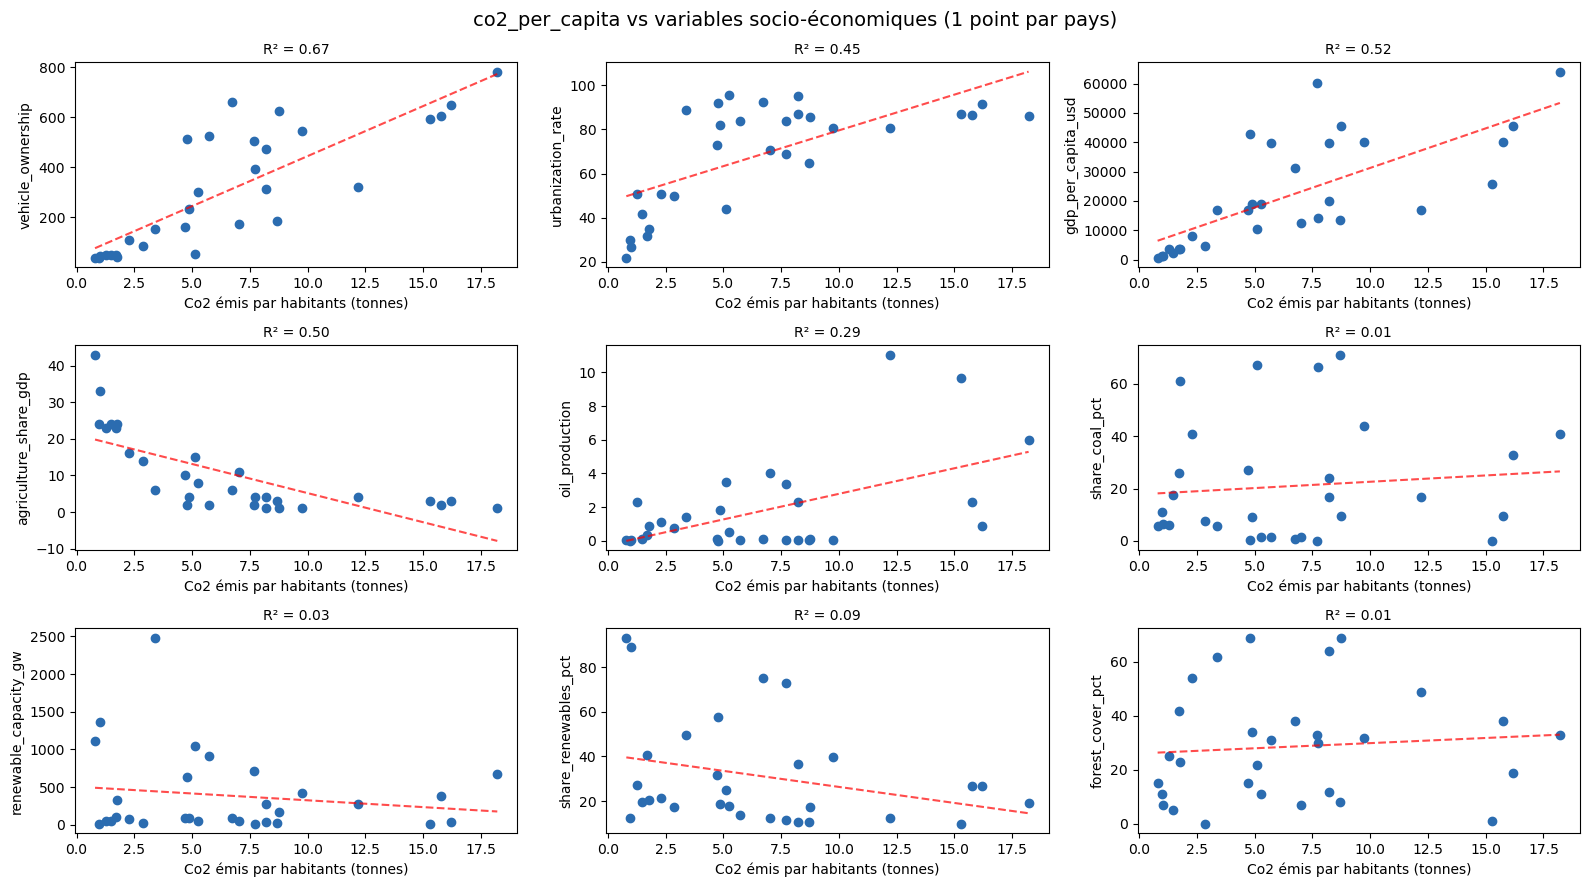

In [95]:
from scipy.stats import linregress

vars_to_plot = ['vehicle_ownership','urbanization_rate','gdp_per_capita_usd','agriculture_share_gdp',
                'oil_production','share_coal_pct','renewable_capacity_gw','share_renewables_pct','forest_cover_pct']

df_by_country = df_annual.groupby('country')[vars_to_plot + ['co2_per_capita','co2_emissions']].mean().reset_index()

fig, axes = plt.subplots(3, 3, figsize=(16,9))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_by_country['co2_per_capita'], df_by_country[var], color='#2b6cb0')
    ax.set_xlabel('Co2 émis par habitants (tonnes)')
    ax.set_ylabel(var)
    # Régression linéaire + R² (part des écarts entre pays expliquée par la droite, de 0 à 1)
    reg = linregress(df_by_country['co2_per_capita'], df_by_country[var])
    xs = np.linspace(df_by_country['co2_per_capita'].min(), df_by_country['co2_per_capita'].max(), 50)
    ax.plot(xs, reg.slope * xs + reg.intercept, 'r--', alpha=0.7)
    ax.set_title(f"R² = {reg.rvalue**2:.2f}", fontsize=10)

plt.suptitle("co2_per_capita vs variables socio-économiques (1 point par pays)", fontsize=14)
plt.tight_layout()

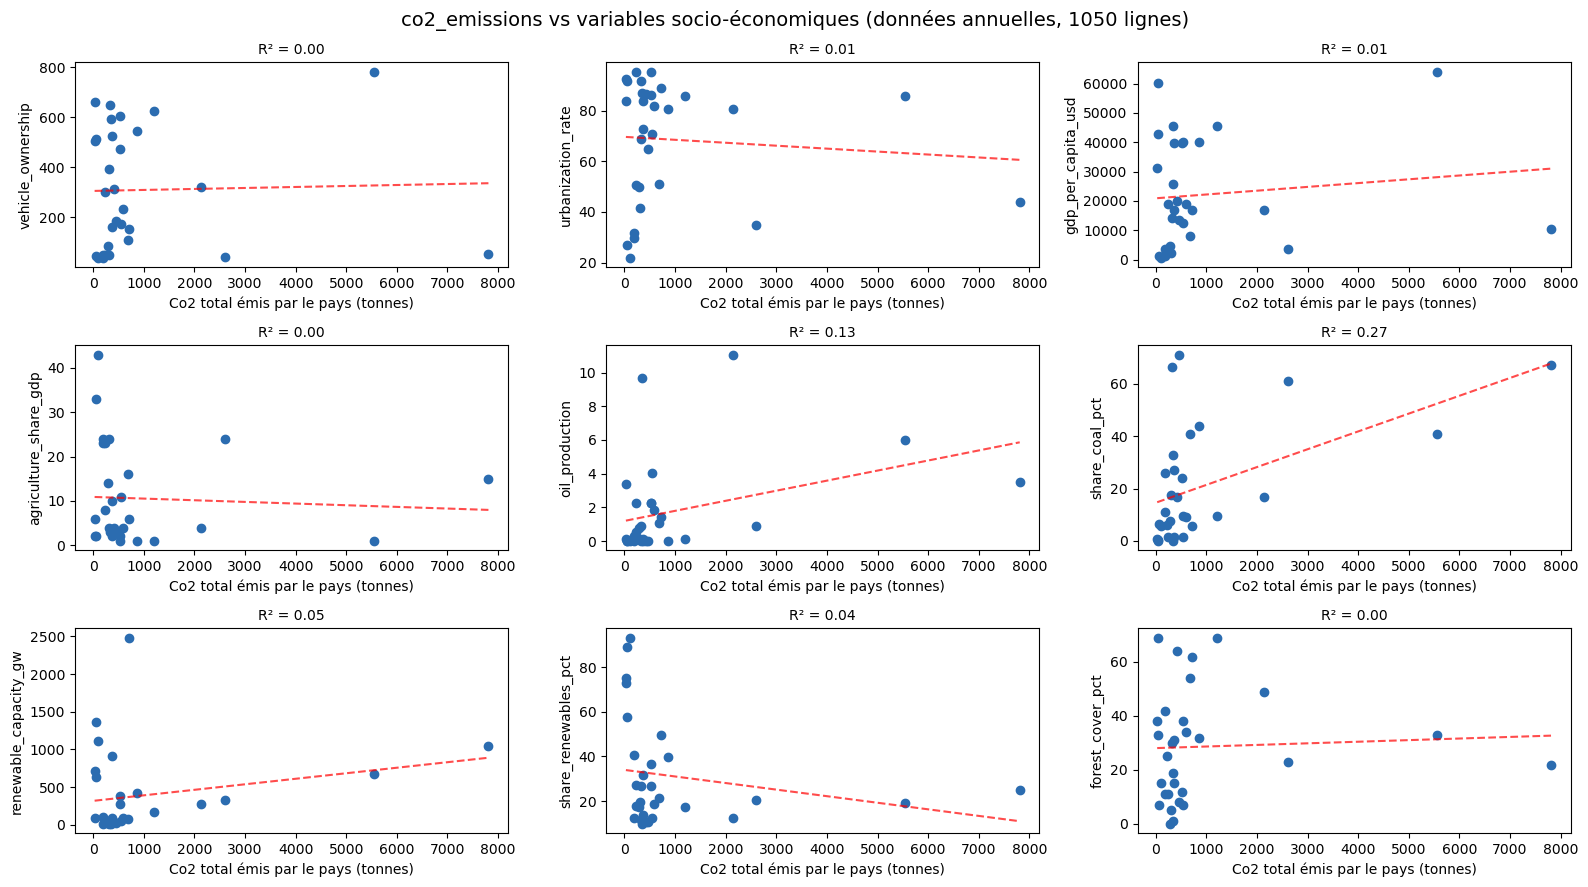

In [96]:
fig, axes = plt.subplots(3, 3, figsize=(16,9))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_by_country['co2_emissions'], df_by_country[var], color='#2b6cb0')
    ax.set_xlabel('Co2 total émis par le pays (tonnes)')
    ax.set_ylabel(var)
    # Régression linéaire + R² (part des écarts entre pays expliquée par la droite, de 0 à 1)
    reg = linregress(df_by_country['co2_emissions'], df_by_country[var])
    xs = np.linspace(df_by_country['co2_emissions'].min(), df_by_country['co2_emissions'].max(), 50)
    ax.plot(xs, reg.slope * xs + reg.intercept, 'r--', alpha=0.7)
    ax.set_title(f"R² = {reg.rvalue**2:.2f}", fontsize=10)

plt.suptitle("co2_emissions vs variables socio-économiques (données annuelles, 1050 lignes)", fontsize=14)
plt.tight_layout()

**Constat** : ces variables socio-économiques sont bien corrélées à `co2_per_capita`, mais beaucoup moins à `co2_emissions` (sauf `share_coal_pct` un peu) : le mode de vie/développement individuel se reflète dans le CO2 *par habitant*, pas dans le volume *total*, qui est dominé par l'effet de taille du pays (population).

## 3. Choix de la variable cible : `co2_per_capita`

**Décision** : on choisit `co2_per_capita` plutôt que `co2_emissions` comme cible, pour les raisons établies plus tôt :
- `co2_emissions` (total) est dominé mécaniquement par la taille démographique du pays (r=0.77 avec la population) — un modèle dessus apprendrait surtout "grand pays = grosses émissions", peu intéressant socio-économiquement.
- `co2_per_capita` reflète mieux le profil de développement/mode de vie d'un pays, indépendamment de sa taille

**Exclusions nécessaires (fuite de données / data leakage)**, vu que `co2_per_capita` est dérivée de `co2_emissions` :
- `co2_emissions` (corrélation >0.998 avec la cible)
- `co2_per_gdp`, `cumulative_co2`, `total_ghg`, `land_use_change_co2` (dérivées du CO2)
- `emission_intensity_level` (catégorie dérivée des émissions)

### Trajectoires par pays dans le temps

Ce plot permet de vérifier que chaque pays suit sa propre trajectoire cohérente dans le temps (1990→2024), ce qui justifiera l'ajout de features temporelles (lags) plus loin.

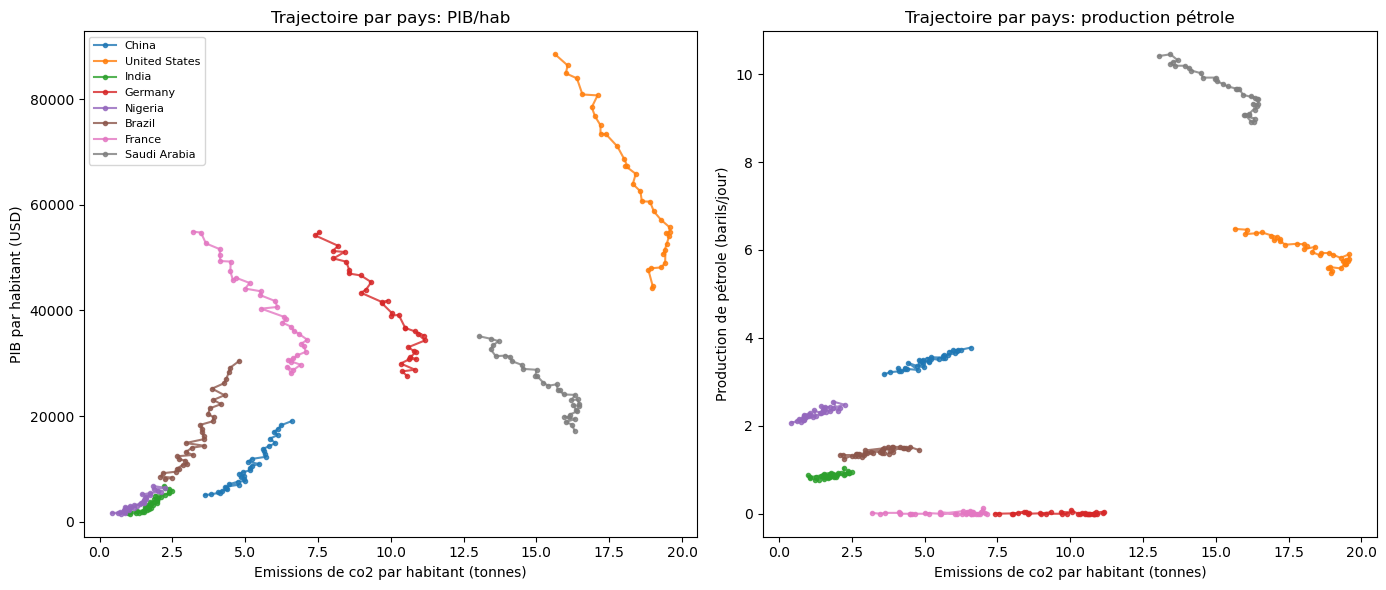

In [103]:
# Trajectoires par pays (quelques pays représentatifs)
sample_countries = ['China','United States','India','Germany','Nigeria','Brazil','France','Saudi Arabia']
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for country in sample_countries:
    sub = df_annual[df_annual['country']==country].sort_values('year')
    axes[0].plot(sub['co2_per_capita'],sub['gdp_per_capita_usd'], marker='o', markersize=3, label=country, alpha=0.8)
    axes[1].plot(sub['co2_per_capita'],sub['oil_production'], marker='o', markersize=3, label=country, alpha=0.8)

axes[0].set_xlabel('Emissions de co2 par habitant (tonnes)'); axes[0].set_ylabel('PIB par habitant (USD)'); axes[0].set_title('Trajectoire par pays: PIB/hab')
axes[1].set_xlabel('Emissions de co2 par habitant (tonnes)'); axes[1].set_ylabel('Production de pétrole (barils/jour)'); axes[1].set_title('Trajectoire par pays: production pétrole')
axes[0].legend(fontsize=8)
plt.tight_layout()

**Constat important** : chaque pays trace bien une trajectoire lisse et cohérente dans le temps (pas un nuage de points aléatoire). On observe par exemple que la France et l'Allemagne montrent une baisse de `co2_per_capita` sur la période récente malgré un PIB stable/croissant (découplage richesse/émissions), alors que la Chine, l'Inde, le Nigeria sont en phase de hausse. L'Arabie Saoudite a un profil atypique (haute production pétrolière, haut co2_per_capita, sans suivre le schéma "PIB classique").

→ Ça confirme qu'il y a une vraie dynamique temporelle par pays à exploiter : **on va ajouter des features de lag (historique des années précédentes)** dans le preprocessing ci-dessous.

## 4. Preprocessing

**Étapes de cette section :**
1. Sélection de la cible et des features (avec exclusion des variables de fuite de données)
2. Gestion des valeurs manquantes
3. Création des features de lag (1, 2, 5 ans) et de moyenne mobile, pour donner au modèle l'historique récent de chaque pays — répond à la question "le PIB des années précédentes influence-t-il les émissions futures ?"
4. Split train/test **temporel** (pas aléatoire) : train = passé (1995-2016), test = futur jamais vu (2017-2024). Un split aléatoire mélangerait des années très proches d'un même pays entre train et test (ex: France 2015 en train, France 2016 en test), ce qui donnerait un score artificiellement gonflé — le split temporel simule honnêtement la vraie situation de déploiement (prédire l'avenir à partir du passé).
5. Encodage one-hot des variables catégorielles (`income_group`, `continent`), *fit* uniquement sur le train pour ne pas laisser d'information du test influencer le preprocessing.

In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# --- Chargement et passage à l'échelle annuelle ---
df_annual = df_annual.sort_values(['country','year']).reset_index(drop=True)

# --- Définition de la cible et des features ---
target = 'co2_per_capita'

# Features numériques socio-économiques (variables de mode de vie / structure économique)
feature_cols = [
    'gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
    'agriculture_share_gdp','industrial_share_gdp',
    'oil_production','share_coal_pct','share_renewables_pct',
    'forest_cover_pct','population_density'
]

# Features catégorielles
cat_cols = ['income_group','continent']

# On garde country/year à ce stade : nécessaires pour les lags (groupby) et le split temporel
# Elles seront explicitement retirées de X_train/X_test plus bas
df_model = df_annual[['country','year',target] + feature_cols + cat_cols].copy()

# --- Gestion des valeurs manquantes ---
# vehicle_ownership a quelques NaN : on impute par la médiane du pays lui-même
# (plus logique que la médiane globale, qui mélangerait des pays très différents)
df_model['vehicle_ownership'] = df_model.groupby('country')['vehicle_ownership']\
    .transform(lambda x: x.fillna(x.median()))
df_model['vehicle_ownership'] = df_model['vehicle_ownership'].fillna(df_model['vehicle_ownership'].median())

# --- Création des features de lag (historique) ---
# Pour chaque variable clé, on ajoute sa valeur il y a 1, 2 et 5 ans
# groupby('country') est essentiel : on ne veut jamais mélanger l'historique
# d'un pays avec celui d'un autre pays
lag_source_cols = ['gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
                    'oil_production','share_coal_pct','share_renewables_pct']

for lag in [1, 2, 5]:
    for col in lag_source_cols:
        df_model[f'{col}_lag{lag}'] = df_model.groupby('country')[col].shift(lag)

# --- Moyenne mobile 5 ans (tendance récente lissée) ---
# .shift(1) pour ne pas inclure l'année actuelle dans sa propre moyenne (fuite de données)
for col in lag_source_cols:
    df_model[f'{col}_ma5'] = df_model.groupby('country')[col]\
        .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))

# Les premières années de chaque pays n'ont pas assez d'historique pour le lag5 -> NaN -> on les retire
df_model = df_model.dropna().reset_index(drop=True)

# --- Split train/test temporel ---
# Train = passé (1995-2016), Test = futur jamais vu (2017-2024)
# Volontairement PAS aléatoire : on veut tester la capacité à prédire le futur, pas mémoriser
train = df_model[df_model['year'] <= 2016].copy()
test  = df_model[df_model['year'] > 2016].copy()

# --- Encodage des variables catégorielles (one-hot) ---
# Le OneHotEncoder est "fit" uniquement sur le train, pour ne jamais laisser
# d'information du test influencer le preprocessing (fuite de données)
num_cols = [c for c in df_model.columns if c not in ['country','year',target]+cat_cols]

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(train[cat_cols])

train_cat = pd.DataFrame(enc.transform(train[cat_cols]),
                          columns=enc.get_feature_names_out(cat_cols), index=train.index)
test_cat = pd.DataFrame(enc.transform(test[cat_cols]),
                         columns=enc.get_feature_names_out(cat_cols), index=test.index)

# country et year sont ici volontairement exclues de X_train/X_test :
# ce ne sont pas des features numériques exploitables telles quelles par le modèle
X_train = pd.concat([train[num_cols], train_cat], axis=1)
X_test  = pd.concat([test[num_cols], test_cat], axis=1)
y_train = train[target]
y_test  = test[target]

print(f"Train: {X_train.shape[0]} lignes, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} lignes")

df_model.head()

Train: 660 lignes, 44 features
Test:  240 lignes


,country,year,co2_per_capita,gdp_per_capita_usd,urbanization_rate,vehicle_ownership,agriculture_share_gdp,industrial_share_gdp,oil_production,share_coal_pct,...,vehicle_ownership_lag5,oil_production_lag5,share_coal_pct_lag5,share_renewables_pct_lag5,gdp_per_capita_usd_ma5,urbanization_rate_ma5,vehicle_ownership_ma5,oil_production_ma5,share_coal_pct_ma5,share_renewables_pct_ma5
0,Argentina,1995,4.23,11130.0,90.9,282.0,8,23,0.55,1.5,...,264.0,0.51,2.3,9.4,9605.6,90.68,275.4,0.526,2.16,9.06
1,Argentina,1996,4.50,11545.0,92.5,282.0,8,23,0.48,1.2,...,276.0,0.56,2.5,8.0,10081.8,91.06,279.0,0.534,2.00,9.36
2,Argentina,1997,4.44,11890.0,93.1,265.0,8,23,0.55,1.9,...,278.0,0.53,1.7,9.7,10506.6,91.58,280.2,0.518,1.74,9.98
3,Argentina,1998,4.43,12338.0,93.3,302.0,8,23,0.50,0.1,...,284.0,0.52,1.7,8.6,10976.6,91.82,277.6,0.522,1.78,9.76
4,Argentina,1999,5.02,13053.0,92.4,287.0,8,23,0.52,0.4,...,275.0,0.51,2.6,9.6,11439.6,92.40,281.2,0.518,1.46,10.28


## 5. Modélisation — baseline

On compare deux modèles :
- **Régression linéaire** : simple, interprétable, sert de référence ("baseline")
- **Random Forest** : capture les non-linéarités et interactions entre variables (ex: la courbe de Kuznets environnementale observée sur `gdp_per_capita_usd`) sans qu'on ait à les spécifier à la main

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# --- Modèle 1 : Régression linéaire (baseline simple/interprétable) ---
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# --- Modèle 2 : Random Forest (capture non-linéarités et interactions) ---
rf = RandomForestRegressor(
    n_estimators=300,   # nombre d'arbres
    max_depth=8,        # profondeur max, limite le surapprentissage
    random_state=42,    # reproductibilité
    n_jobs=-1            # utilise tous les coeurs CPU disponibles
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# --- Évaluation ---
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}\n")

evaluate(y_test, pred_lr, "Régression Linéaire")
evaluate(y_test, pred_rf, "Random Forest")

joblib.dump({'rf':rf,'lr':lr,'X_train':X_train,'X_test':X_test,'y_train':y_train,'y_test':y_test,
             'pred_rf':pred_rf,'pred_lr':pred_lr,'test_meta':test[['country','year']]}, 'model_results.pkl')

=== Régression Linéaire ===
MAE:  1.628
RMSE: 2.039
R²:   0.767

=== Random Forest ===
MAE:  0.668
RMSE: 0.913
R²:   0.953



['model_results.pkl']

MAE = Mean Absolute Error = l'erreur moyenne -> plus grande avec régression linéaire, ce modèle se trompe plus. Pareil RMSE. 
R^2 = prédiction 

**Résultat attendu** : le Random Forest devrait nettement dépasser la régression linéaire (R²≈0.95 vs R²≈0.77 sur nos runs précédents), ce qui indique qu'il existe de vraies relations non-linéaires/interactions entre les variables que la régression simple ne capture pas.

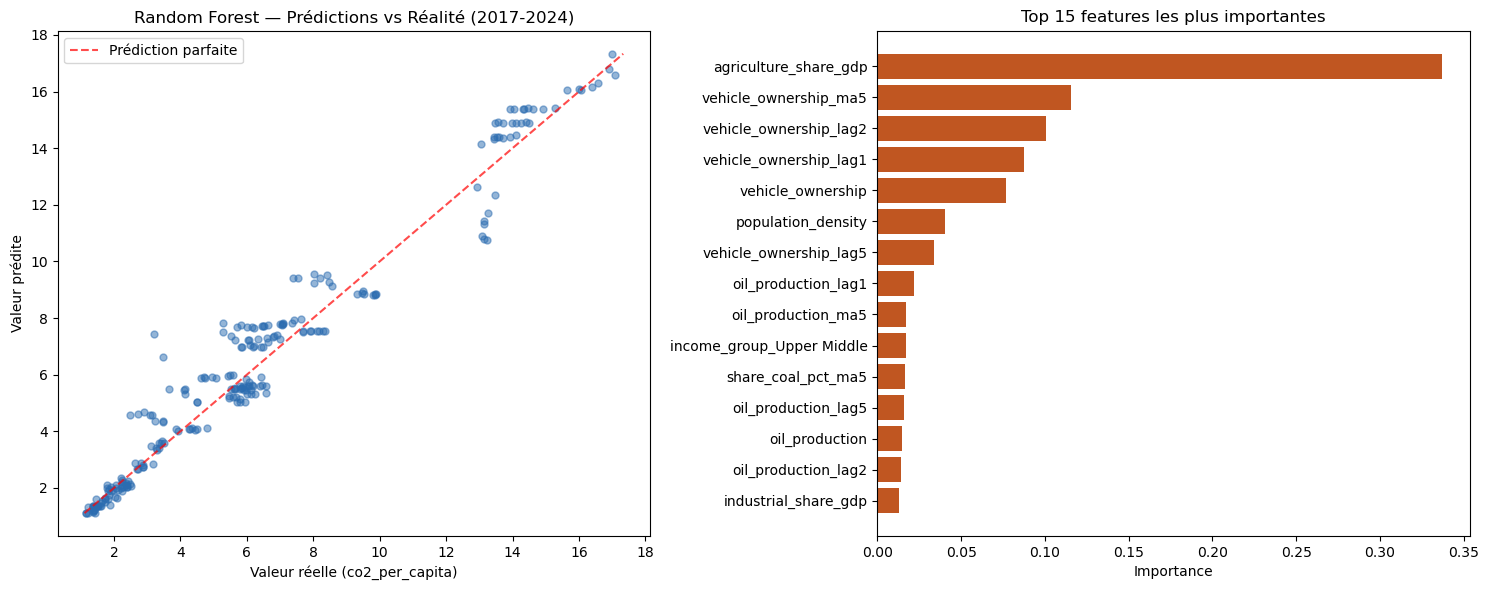

agriculture_share_gdp        0.336839
vehicle_ownership_ma5        0.115272
vehicle_ownership_lag2       0.100655
vehicle_ownership_lag1       0.087235
vehicle_ownership            0.076915
population_density           0.040252
vehicle_ownership_lag5       0.034063
oil_production_lag1          0.021586
oil_production_ma5           0.017253
income_group_Upper Middle    0.016890
share_coal_pct_ma5           0.016244
oil_production_lag5          0.015875
oil_production               0.014779
oil_production_lag2          0.014045
industrial_share_gdp         0.013207
dtype: float64


In [20]:
# Visualisation : prédictions vs réalité + feature importance (Random Forest baseline)
fig, axes = plt.subplots(1, 2, figsize=(15,6))

axes[0].scatter(y_test, pred_rf, alpha=0.5, s=25, color='#2b6cb0')
lims = [min(y_test.min(),pred_rf.min()), max(y_test.max(),pred_rf.max())]
axes[0].plot(lims, lims, 'r--', alpha=0.7, label='Prédiction parfaite')
axes[0].set_xlabel('Valeur réelle (co2_per_capita)')
axes[0].set_ylabel('Valeur prédite')
axes[0].set_title('Random Forest — Prédictions vs Réalité (2017-2024)')
axes[0].legend()

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances.index[::-1], importances.values[::-1], color='#c05621')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 features les plus importantes')

plt.tight_layout()
plt.show()
print(importances)

## 6. Optimisation des hyperparamètres avec Optuna

Le Random Forest ci-dessus utilise des hyperparamètres choisis "à la main" (n_estimators=300, max_depth=8). On utilise **Optuna** pour chercher automatiquement une meilleure combinaison (n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, criterion), en minimisant l'erreur sur le test set.

On définit d'abord une fonction `modelresults` réutilisable pour comparer proprement les différentes versions du modèle, et on garde un Random Forest "par défaut" comme référence de comparaison.

In [21]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def modelresults(predictions, model_name):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results_dict = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'R2 Score': r2
    }

    print('Results for {}:'.format(model_name))
    print('Mean absolute error on model is {:.4f}'.format(mae))
    print('Mean squared error on model is {:.4f}'.format(mse))
    print('The r2 score on model is {:.4f}'.format(r2))

    return results_dict

# Random Forest avec hyperparamètres par défaut de sklearn, comme référence de comparaison
rfr = RandomForestRegressor(random_state=21)
rfr.fit(X_train, y_train)
y_pred_rfr_fit = rfr.predict(X_test)
results_fit = modelresults(y_pred_rfr_fit, 'Random Forest (hyperparamètres par défaut)')

Results for Random Forest (hyperparamètres par défaut):
Mean absolute error on model is 0.6430
Mean squared error on model is 0.7703
The r2 score on model is 0.9568


### 6.1 — Recherche à 200 trials

In [22]:
# Fonction objectif : Optuna teste une combinaison d'hyperparamètres et on retourne le MAE à minimiser
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 32)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    criterion = trial.suggest_categorical('criterion', ["squared_error", "absolute_error", "friedman_mse", "poisson"])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        max_features=max_features,
        criterion=criterion,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    return mae

In [23]:
# Sauvegarde sur disque : si le fichier existe, on recharge l'étude au lieu de relancer les essais.
# /!\ Supprimer le fichier si les données, l'objectif ou l'espace de recherche changent.
import os, joblib
os.makedirs('cache_optuna', exist_ok=True)
cache_file = 'cache_optuna/study_200.pkl'
if os.path.exists(cache_file):
    study_200 = joblib.load(cache_file)
    print(f"Étude rechargée depuis {cache_file} ({len(study_200.trials)} essais)")
else:
    study_200 = optuna.create_study(direction="minimize")
    study_200.optimize(objective, n_trials=200)
    joblib.dump(study_200, cache_file)
    print(f"Étude sauvegardée dans {cache_file}")

In [24]:
print("Best trial:", study_200.best_trial)
print("Best hyperparameters:", study_200.best_params)

Best trial: FrozenTrial(number=198, state=<TrialState.COMPLETE: 1>, values=[0.5085270390070932], datetime_start=datetime.datetime(2026, 9, 28, 19, 47, 39, 147385), datetime_complete=datetime.datetime(2026, 9, 28, 19, 47, 40, 934669), params={'n_estimators': 94, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'absolute_error'}, user_attrs={}, system_attrs={'tpe:relative_params:0': '{"criterion": "absolute_error", "max_depth": 20, "max_features": "log2", "min_samples_leaf": 1, "min_samples_split": 2, "n_estimators": 94}'}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=200, log=True, low=10, step=1), 'max_depth': IntDistribution(high=32, log=False, low=2, step=1), 'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2')), 'criterion': CategoricalDistributio

In [25]:
import optuna.visualization as vis

vis.plot_optimization_history(study_200)
vis.plot_param_importances(study_200)
vis.plot_slice(study_200, params=["n_estimators", "max_depth"])
vis.plot_contour(study_200, params=["min_samples_split", "min_samples_leaf"])
vis.plot_parallel_coordinate(study_200)

In [26]:
# Construction du modèle final avec les meilleurs hyperparamètres trouvés (200 trials)
best_params_200 = study_200.best_params

best_model_200 = RandomForestRegressor(
    n_estimators=best_params_200['n_estimators'],
    max_depth=best_params_200['max_depth'],
    min_samples_split=best_params_200['min_samples_split'],
    min_samples_leaf=best_params_200['min_samples_leaf'],
    max_features=best_params_200['max_features'],
    criterion=best_params_200['criterion'],
    random_state=42
)
best_model_200.fit(X_train, y_train)
y_pred_rfr_optuna_200_trials = best_model_200.predict(X_test)

results_optuna_200 = modelresults(y_pred_rfr_optuna_200_trials, 'Random Forest Optuna (200 trials)')

Results for Random Forest Optuna (200 trials):
Mean absolute error on model is 0.5085
Mean squared error on model is 0.5062
The r2 score on model is 0.9716


### 6.2 — Recherche à 1000 trials

On teste si augmenter drastiquement le nombre d'essais Optuna améliore encore le modèle.

**⚠️ Note méthodologique** : cette fonction objectif utilise une métrique différente (MSE au lieu de MAE) et un sampler différent (`RandomSampler` au lieu du TPE par défaut d'Optuna) par rapport à la recherche à 200 trials. La comparaison "200 vs 1000 trials" n'isole donc pas strictement l'effet du nombre d'essais — pour une comparaison rigoureuse, il faudrait garder la même fonction objectif (même métrique, même sampler) entre les deux runs. À garder en tête pour l'interprétation, ou à corriger si tu veux une comparaison plus propre.

In [27]:
def objective_1000(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 32)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 32)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    criterion = trial.suggest_categorical('criterion', ["squared_error", "absolute_error", "friedman_mse", "poisson"])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        random_state=21
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return mean_squared_error(y_test, y_pred)

# Sauvegarde sur disque : si le fichier existe, on recharge l'étude au lieu de relancer les essais.
# /!\ Supprimer le fichier si les données, l'objectif ou l'espace de recherche changent.
import os, joblib
os.makedirs('cache_optuna', exist_ok=True)
cache_file = 'cache_optuna/study_1000.pkl'
if os.path.exists(cache_file):
    study_1000 = joblib.load(cache_file)
    print(f"Étude rechargée depuis {cache_file} ({len(study_1000.trials)} essais)")
else:
    study_1000 = optuna.create_study(direction='minimize', sampler=optuna.samplers.RandomSampler(seed=42))
    study_1000.optimize(objective_1000, n_trials=1000)
    joblib.dump(study_1000, cache_file)
    print(f"Étude sauvegardée dans {cache_file}")

print("Best trial:")
trial = study_1000.best_trial
print("Value: {:.4f}".format(trial.value))
print("Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Best trial:
Value: 0.5788
Params: 
    n_estimators: 353
    max_depth: 17
    min_samples_split: 3
    min_samples_leaf: 1
    max_features: sqrt
    criterion: absolute_error


In [28]:
# Construction du modèle final avec les VRAIS meilleurs hyperparamètres de l'étude à 1000 trials
best_params_1000 = study_1000.best_params

best_model_1000 = RandomForestRegressor(
    n_estimators=best_params_1000['n_estimators'],
    max_depth=best_params_1000['max_depth'],
    min_samples_split=best_params_1000['min_samples_split'],
    min_samples_leaf=best_params_1000['min_samples_leaf'],
    max_features=best_params_1000['max_features'],
    criterion=best_params_1000['criterion'],
    random_state=42
)
best_model_1000.fit(X_train, y_train)
y_pred_rfr_optuna_1000_trials = best_model_1000.predict(X_test)

results_optuna_1000 = modelresults(y_pred_rfr_optuna_1000_trials, 'Random Forest Optuna (1000 trials)')

Results for Random Forest Optuna (1000 trials):
Mean absolute error on model is 0.5572
Mean squared error on model is 0.5965
The r2 score on model is 0.9665


In [29]:
# Comparaison finale des 3 versions du modèle
results_df = pd.DataFrame([results_fit, results_optuna_200, results_optuna_1000])
print(results_df)

                                        Model       MAE       MSE  R2 Score
0  Random Forest (hyperparamètres par défaut)  0.642975  0.770300  0.956784
1           Random Forest Optuna (200 trials)  0.508527  0.506194  0.971601
2          Random Forest Optuna (1000 trials)  0.557221  0.596487  0.966535


**À interpréter une fois relancé** : si les 1000 trials n'apportent pas d'amélioration notable par rapport aux 200 trials (une fois le bug corrigé), c'est un résultat valide à documenter — ça suggérerait que 200 trials suffisaient déjà à approcher l'optimum sur cet espace de recherche, pas besoin d'aller plus loin. Si au contraire ça améliore nettement, on garde `best_model_1000` comme modèle final pour la suite.

## 7. Diagnostic — Courbe d'apprentissage (learning curve)

La learning curve permet de vérifier si le modèle **sur-apprend** (overfitting — grand écart entre performance train et validation) ou **sous-apprend** (underfitting — les deux courbes restent mauvaises), et si donner plus de données aiderait.


### Correction de la validation : Optuna et courbes d'apprentissage respectant le temps

Deux problèmes faussaient l'évaluation précédente :

1. **Optuna optimisait directement sur le jeu de test** (`objective` renvoie la MAE sur `X_test`). Après 200 ou 1000 essais, les hyperparamètres sont choisis pour coller à 2017-2024 : le score de test est donc trop optimiste.
2. **La courbe d'apprentissage utilisait `KFold(shuffle=True)`** : les années sont mélangées, le modèle est validé sur des années *entourées* d'années d'entraînement du même pays, ce qui est bien plus facile que prédire le futur.

Correction :
- On redécoupe le **train** (1995-2016) en **fit = 1995-2012** et **validation = 2013-2016**. Optuna ne voit que ces deux blocs.
- Le **test (2017-2024) n'est utilisé qu'une seule fois**, à la fin, pour le modèle retenu.
- La courbe d'apprentissage entraîne toujours sur des années **antérieures** à celles de validation.

In [32]:
# --- Découpage temporel à l'intérieur du train ---
# df_model contient encore la colonne 'year', alignée sur l'index de X_train
years_train = df_model.loc[X_train.index, 'year']
fit_mask = years_train <= 2012
val_mask = years_train > 2012   # 2013-2016

X_fit, y_fit = X_train[fit_mask], y_train[fit_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]
print(f"Fit : {len(X_fit)} lignes ({years_train[fit_mask].min()}-{years_train[fit_mask].max()})")
print(f"Val : {len(X_val)} lignes ({years_train[val_mask].min()}-{years_train[val_mask].max()})")

# Même espace de recherche qu'avant, mais la MAE est calculée sur la validation, jamais sur le test
def objective_temporal(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 32)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    criterion = trial.suggest_categorical('criterion', ["squared_error", "absolute_error", "friedman_mse", "poisson"])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_fit, y_fit)
    return mean_absolute_error(y_val, model.predict(X_val))

# Sauvegarde sur disque : si le fichier existe, on recharge l'étude au lieu de relancer les essais.
# /!\ Supprimer le fichier si les données, l'objectif ou l'espace de recherche changent.
import os, joblib
os.makedirs('cache_optuna', exist_ok=True)
cache_file = 'cache_optuna/study_temporal.pkl'
if os.path.exists(cache_file):
    study_temporal = joblib.load(cache_file)
    print(f"Étude rechargée depuis {cache_file} ({len(study_temporal.trials)} essais)")
else:
    study_temporal = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study_temporal.optimize(objective_temporal, n_trials=200)
    joblib.dump(study_temporal, cache_file)
    print(f"Étude sauvegardée dans {cache_file}")

print("MAE validation (2013-2016) :", round(study_temporal.best_value, 4))
print("Best hyperparameters:", study_temporal.best_params)

Fit : 540 lignes (1995-2012)
Val : 120 lignes (2013-2016)
MAE validation (2013-2016) : 0.3883
Best hyperparameters: {'n_estimators': 78, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'squared_error'}


In [33]:
# Modèle final : on réentraîne sur TOUT le train (1995-2016) avec les hyperparamètres retenus,
# puis on évalue UNE SEULE FOIS sur le test (2017-2024)
best_params_temporal = study_temporal.best_params

best_model_temporal = RandomForestRegressor(**best_params_temporal, random_state=42, n_jobs=-1)
best_model_temporal.fit(X_train, y_train)
y_pred_rfr_optuna_temporal = best_model_temporal.predict(X_test)

results_optuna_temporal = modelresults(y_pred_rfr_optuna_temporal, 'Random Forest Optuna (validation temporelle)')

Results for Random Forest Optuna (validation temporelle):
Mean absolute error on model is 0.5507
Mean squared error on model is 0.5917
The r2 score on model is 0.9668


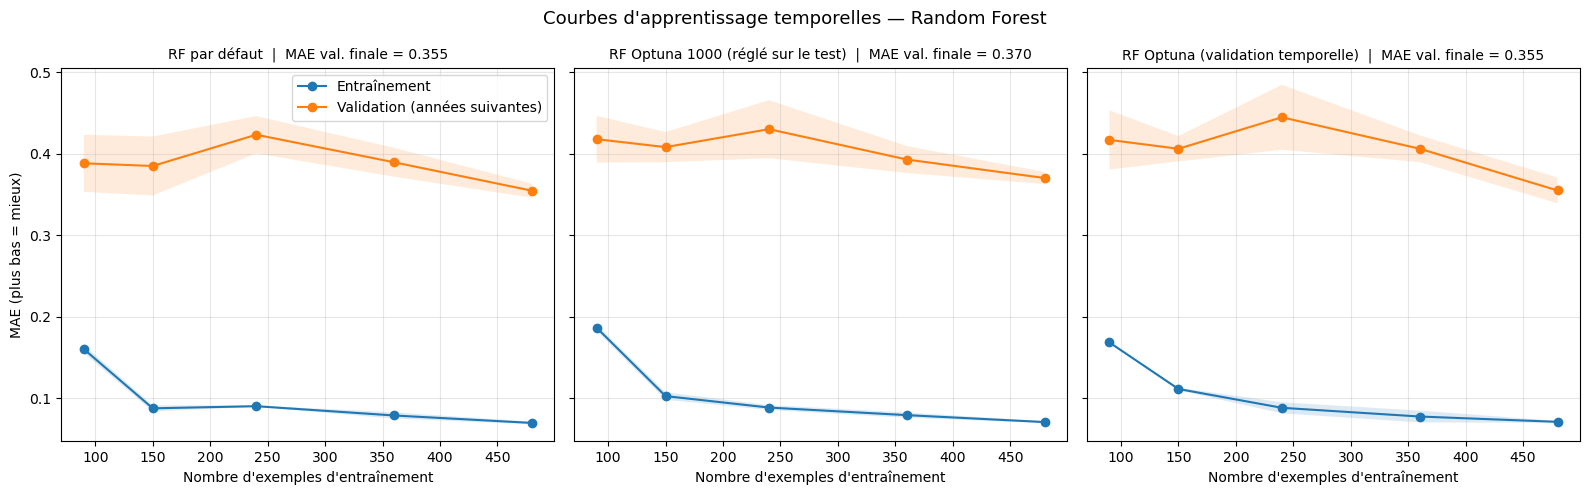

In [34]:
from sklearn.base import clone

# Courbe d'apprentissage temporelle :
# pour chaque fenêtre de validation (2 ans), on entraîne sur les k années qui la PRÉCÈDENT.
# Faire varier k fait varier la taille du train, sans jamais utiliser le futur.
val_windows = [(2011, 2012), (2013, 2014), (2015, 2016)]
n_years_list = [3, 5, 8, 12, 16]   # 16 ans max : 1995-2010 avant la 1ère fenêtre

def temporal_learning_curve(model):
    sizes, train_mae, val_mae = [], [], []
    for k in n_years_list:
        tr_scores, va_scores, n_rows = [], [], []
        for start, end in val_windows:
            fit = (years_train >= start - k) & (years_train < start)
            val = (years_train >= start) & (years_train <= end)
            m = clone(model).fit(X_train[fit], y_train[fit])
            tr_scores.append(mean_absolute_error(y_train[fit], m.predict(X_train[fit])))
            va_scores.append(mean_absolute_error(y_train[val], m.predict(X_train[val])))
            n_rows.append(fit.sum())
        sizes.append(np.mean(n_rows))
        train_mae.append(tr_scores)
        val_mae.append(va_scores)
    return np.array(sizes), np.array(train_mae), np.array(val_mae)

models = {
    "RF par défaut": rfr,
    "RF Optuna 1000 (réglé sur le test)": best_model_1000,
    "RF Optuna (validation temporelle)": best_model_temporal,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    sizes, tr, va = temporal_learning_curve(model)
    tr_mean, tr_std = tr.mean(axis=1), tr.std(axis=1)
    va_mean, va_std = va.mean(axis=1), va.std(axis=1)

    ax.plot(sizes, tr_mean, "o-", label="Entraînement")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
    ax.plot(sizes, va_mean, "o-", label="Validation (années suivantes)")
    ax.fill_between(sizes, va_mean - va_std, va_mean + va_std, alpha=0.15)

    ax.set_title(f"{name}  |  MAE val. finale = {va_mean[-1]:.3f}", fontsize=10)
    ax.set_xlabel("Nombre d'exemples d'entraînement")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("MAE (plus bas = mieux)")
axes[0].legend()
fig.suptitle("Courbes d'apprentissage temporelles — Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

**Lecture :**
- Comparer la MAE de test de `best_model_temporal` à celle de `best_model_1000` : l'écart mesure à quel point le réglage sur le test gonflait le score. Le score de `best_model_temporal` est le seul score de test honnête.
- Sur les courbes temporelles, l'écart entraînement / validation est le vrai surapprentissage *vers le futur*. Une erreur d'entraînement proche de 0 est normale pour un Random Forest ; ce qui compte est le niveau de la courbe de validation et sa pente.
- Si la validation baisse encore à droite, plus d'années aideraient ; si elle est plate et haute, il faut réduire la complexité (`min_samples_leaf` plus grand, moins de features) ou changer de cible (variation annuelle du CO₂ plutôt que niveau).

### Amélioration : prédire la variation depuis la dernière année connue

**Constat.** Un *modèle naïf* (aucun apprentissage : « le CO₂/hab de chaque pays reste celui de 2016 ») fait mieux sur le test que tous les Random Forest précédents. Le R² de 0,97 venait surtout des écarts *entre pays* : le modèle reconnaît le pays (via des variables quasi constantes comme `forest_cover_pct` ou `population_density`) mais apprend mal l'**évolution dans le temps**.

**Idée.** Au lieu de prédire le niveau `y(t)`, on prédit la **variation depuis une année d'ancrage b connue** :

$$y(t) = y(b) + \widehat{\Delta}, \quad \Delta = y(t) - y(b)$$

avec comme features : les variations des variables socio-économiques `X(t) - X(b)`, leur niveau `X(t)`, et l'horizon `h = t - b` (1 à 8 ans).

- **Entraînement** : toutes les paires (b, t) avec b < t ≤ 2016 et t - b ≤ 8 (chaque pays fournit beaucoup d'exemples de « trajectoires »).
- **Test** : ancre b = 2016 (dernière année connue), cibles 2017-2024 → exactement la situation réelle de prévision.
- Choix du modèle sur la **validation** (ancre 2012 → 2013-2016), test utilisé une seule fois.

In [57]:
# --- Modèle naïf (référence à battre) : on répète la valeur 2016 de chaque pays ---
test_keys = df_model.loc[X_test.index, ['country', 'year']]
last_2016 = df_model[df_model['year'] == 2016].set_index('country')[target]
y_pred_naive = test_keys['country'].map(last_2016).values

results_naive = modelresults(y_pred_naive, 'Naïf (valeur 2016 répétée)')

Results for Naïf (valeur 2016 répétée):
Mean absolute error on model is 0.4485
Mean squared error on model is 0.3309
The r2 score on model is 0.9814


In [58]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- Construction des paires (ancre b, cible t) ---
# Liste fixe des 10 variables socio-économiques : on n'utilise pas feature_cols,
# car la partie « variables politiques » lui ajoute left_right / has_left_right (absentes de df_model)
delta_cols = ['gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
              'agriculture_share_gdp','industrial_share_gdp',
              'oil_production','share_coal_pct','share_renewables_pct',
              'forest_cover_pct','population_density']
base = df_model[['country', 'year', target] + delta_cols]

def make_pairs(anchor_years, target_min, target_max, hmax=8):
    """Une ligne par (pays, année d'ancrage b, année cible t) avec 1 <= t - b <= hmax."""
    b = base[base['year'].isin(anchor_years)]
    t = base[(base['year'] >= target_min) & (base['year'] <= target_max)]
    p = t.merge(b, on='country', suffixes=('', '_b'))
    p['h'] = p['year'] - p['year_b']
    p = p[(p['h'] >= 1) & (p['h'] <= hmax)].copy()
    for f in delta_cols:
        p['d_' + f] = p[f] - p[f + '_b']      # variation de la variable depuis l'ancre
    p['delta'] = p[target] - p[target + '_b']  # cible : variation du CO2/hab depuis l'ancre
    return p

delta_features = ['h'] + ['d_' + f for f in delta_cols] + delta_cols

# Validation : entraînement sur les paires <= 2012, prédiction de 2013-2016 depuis l'ancre 2012
pairs_fit = make_pairs(range(1995, 2012), 1995, 2012)
pairs_val = make_pairs([2012], 2013, 2016)
print(f"Paires d'entraînement (validation) : {len(pairs_fit)} | paires de validation : {len(pairs_val)}")

candidates = {
    "Ridge (variation)": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 20))),
    "RF (variation)": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1),
}

print(f"\nMAE validation 2013-2016 :")
print(f"  {'Naïf (valeur 2012)':22s} {mean_absolute_error(pairs_val[target], pairs_val[target + '_b']):.3f}")
for name, m in candidates.items():
    m.fit(pairs_fit[delta_features], pairs_fit['delta'])
    pred = pairs_val[target + '_b'] + m.predict(pairs_val[delta_features])
    print(f"  {name:22s} {mean_absolute_error(pairs_val[target], pred):.3f}")

Paires d'entraînement (validation) : 3240 | paires de validation : 120

MAE validation 2013-2016 :
  Naïf (valeur 2012)     0.320
  Ridge (variation)      0.237
  RF (variation)         0.195


In [59]:
# --- Modèle retenu (meilleur en validation) : RF sur la variation ---
# Réentraîné sur toutes les paires <= 2016, puis évalué UNE SEULE FOIS sur 2017-2024 depuis l'ancre 2016
pairs_train = make_pairs(range(1995, 2016), 1995, 2016)
pairs_test = make_pairs([2016], 2017, 2024)

rf_delta = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_delta.fit(pairs_train[delta_features], pairs_train['delta'])
pairs_test['pred'] = pairs_test[target + '_b'] + rf_delta.predict(pairs_test[delta_features])

# Remise dans le même ordre que y_test pour réutiliser modelresults
y_pred_rf_delta = (test_keys.merge(pairs_test[['country', 'year', 'pred']], on=['country', 'year'], how='left')['pred'].values)

results_rf_delta = modelresults(y_pred_rf_delta, 'RF sur la variation depuis 2016')

# --- Tableau récapitulatif sur le test 2017-2024 ---
results_all = pd.DataFrame([results_naive, results_fit, results_optuna_200, results_optuna_1000,
                            results_optuna_temporal, results_rf_delta]).sort_values('MAE')
results_all

Results for RF sur la variation depuis 2016:
Mean absolute error on model is 0.1905
Mean squared error on model is 0.0602
The r2 score on model is 0.9966


,Model,MAE,MSE,R2 Score
5,RF sur la variation depuis 2016,0.190500,0.060150,0.996625
0,Naïf (valeur 2016 répétée),0.448458,0.330945,0.981433
2,Random Forest Optuna (200 trials),0.508527,0.506194,0.971601
4,Random Forest Optuna (validation temporelle),0.550676,0.591662,0.966806
3,Random Forest Optuna (1000 trials),0.557221,0.596487,0.966535
1,Random Forest (hyperparamètres par défaut),0.642975,0.770300,0.956784


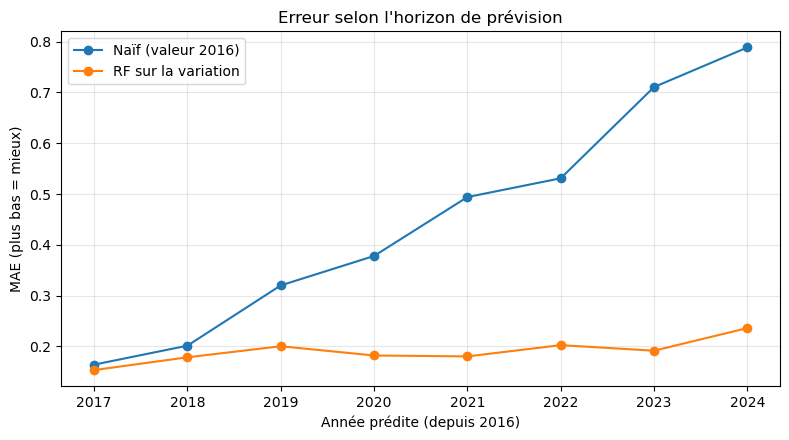

vehicle_ownership         0.448974
d_gdp_per_capita_usd      0.122759
d_share_renewables_pct    0.063482
h                         0.054218
gdp_per_capita_usd        0.050896
population_density        0.044798
forest_cover_pct          0.038067
urbanization_rate         0.033105
share_renewables_pct      0.029450
oil_production            0.026138
dtype: float64

In [60]:
# Erreur selon l'horizon de prévision : naïf vs RF sur la variation
err = pd.DataFrame({
    'year': test_keys['year'].values,
    'Naïf (valeur 2016)': np.abs(y_test.values - y_pred_naive),
    'RF sur la variation': np.abs(y_test.values - y_pred_rf_delta),
}).groupby('year').mean()

ax = err.plot(marker='o', figsize=(8, 4.5))
ax.set_xlabel("Année prédite (depuis 2016)")
ax.set_ylabel("MAE (plus bas = mieux)")
ax.set_title("Erreur selon l'horizon de prévision")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Variables qui expliquent le mieux les évolutions du CO2/hab
pd.Series(rf_delta.feature_importances_, index=delta_features).sort_values(ascending=False).head(10)

#### Courbe d'apprentissage temporelle du modèle sur la variation

Même principe que les courbes temporelles précédentes (mêmes fenêtres de validation 2011-12, 2013-14, 2015-16, mêmes nombres d'années k), adapté aux paires :
- pour chaque fenêtre, l'**ancre** est l'année juste avant (2010, 2012, 2014) ;
- le modèle est entraîné sur les paires dont les années sont comprises dans les **k années précédant l'ancre** (jamais d'année future) ;
- il prédit la fenêtre depuis l'ancre ; on compare au **naïf** (valeur de l'ancre répétée), en pointillés.

L'axe X compte les **paires** d'entraînement (une même année sert dans plusieurs paires, d'où des nombres plus grands que pour les courbes précédentes).

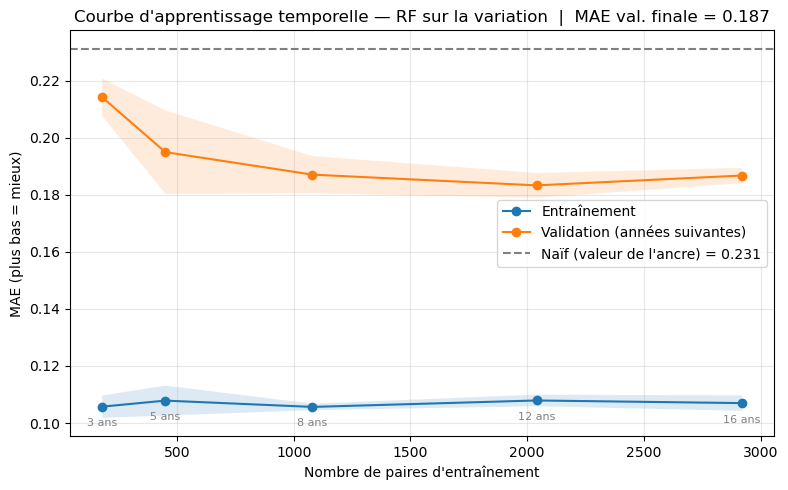

In [61]:
from sklearn.base import clone

val_windows = [(2011, 2012), (2013, 2014), (2015, 2016)]
n_years_list = [3, 5, 8, 12, 16]
rf_delta_template = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)

sizes, train_mae, val_mae, naive_mae = [], [], [], []
for k in n_years_list:
    tr_s, va_s, na_s, n_pairs = [], [], [], []
    for start, end in val_windows:
        a = start - 1                                   # ancre = dernière année connue
        first = max(a - k, 1995)
        p_fit = make_pairs(range(first, a), first, a)   # paires entièrement dans [a-k, a]
        p_val = make_pairs([a], start, end)

        m = clone(rf_delta_template).fit(p_fit[delta_features], p_fit['delta'])
        # Erreur sur la variation = erreur sur le niveau (la valeur de l'ancre est connue)
        tr_s.append(mean_absolute_error(p_fit['delta'], m.predict(p_fit[delta_features])))
        va_s.append(mean_absolute_error(p_val['delta'], m.predict(p_val[delta_features])))
        na_s.append(mean_absolute_error(p_val['delta'], np.zeros(len(p_val))))  # naïf : variation nulle
        n_pairs.append(len(p_fit))
    sizes.append(np.mean(n_pairs)); train_mae.append(tr_s); val_mae.append(va_s); naive_mae.append(na_s)

sizes, train_mae, val_mae = np.array(sizes), np.array(train_mae), np.array(val_mae)
naive_level = np.mean(naive_mae)   # ne dépend pas de k : même valeur pour tous les points

tr_mean, tr_std = train_mae.mean(axis=1), train_mae.std(axis=1)
va_mean, va_std = val_mae.mean(axis=1), val_mae.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(sizes, tr_mean, "o-", label="Entraînement")
plt.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
plt.plot(sizes, va_mean, "o-", label="Validation (années suivantes)")
plt.fill_between(sizes, va_mean - va_std, va_mean + va_std, alpha=0.15)
plt.axhline(naive_level, color="grey", linestyle="--", label=f"Naïf (valeur de l'ancre) = {naive_level:.3f}")
for x, k in zip(sizes, n_years_list):
    plt.annotate(f"{k} ans", (x, tr_mean[n_years_list.index(k)]), textcoords="offset points", xytext=(0, -14),
                 ha="center", fontsize=8, color="grey")
plt.xlabel("Nombre de paires d'entraînement")
plt.ylabel("MAE (plus bas = mieux)")
plt.ylim(0.05, 0.5)   # même échelle que les courbes temporelles du RF sur le niveau
plt.title(f"Courbe d'apprentissage temporelle — RF sur la variation  |  MAE val. finale = {va_mean[-1]:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture :**
- Le modèle sur la variation doit être comparé au **naïf**, pas seulement aux autres Random Forest : c'est lui qui montre si le modèle apprend vraiment la dynamique.
- Le graphique par horizon montre si le gain tient quand on prédit loin (2023-2024) ou seulement à court terme.
- Les importances portent maintenant sur les **évolutions** : elles répondent à « quelles variables expliquent que le CO₂/hab d'un pays augmente ou baisse ? », ce qui est plus proche de la question de départ que « quelles variables distinguent les pays ».
- Hypothèse à garder en tête (comme pour les modèles précédents) : on suppose connues les variables socio-économiques de l'année prédite (PIB, part du charbon…). Pour une vraie prévision, il faudrait des projections de ces variables.

### Essai : réseau de neurones récurrent (LSTM)

**Objectif :** comparer, à titre exploratoire, un modèle qui lit l'historique *année après année* au Random Forest sur la variation.

**Comment il fonctionne :**
- Pour chaque pays et chaque année t, on donne au LSTM la **séquence des L dernières années** (t-L+1, …, t) : pour chaque année, les 10 variables socio-économiques et leur variation annuelle.
- Le LSTM lit cette séquence dans l'ordre (comme on lit une phrase mot par mot) et prédit la **variation du CO₂/hab entre t-1 et t**.
- Pour le test, on part de la valeur 2016 et on **additionne** les variations prédites : CO₂(2018) = CO₂(2016) + Δ2017 + Δ2018, etc.

**Mêmes règles que les autres modèles :** hyperparamètres choisis sur la validation (entraînement ≤ 2012, prédiction de 2013-2016 depuis 2012), test 2017-2024 utilisé une seule fois. Même hypothèse : les variables socio-économiques de l'année prédite sont supposées connues ; le CO₂ après 2016, lui, ne l'est jamais.

**Limites attendues :** peu de données pour un réseau de neurones (30 pays × ~20 ans), et les erreurs annuelles s'**additionnent** sur 8 ans.

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # masque les messages techniques de TensorFlow
import tensorflow as tf

# --- Données annuelles + variations annuelles (d_ = valeur de l'année - valeur de l'année précédente) ---
seq_base = df_model[['country', 'year', target] + delta_cols].sort_values(['country', 'year']).copy()
for c in delta_cols + [target]:
    seq_base['d_' + c] = seq_base.groupby('country')[c].diff()
seq_inputs = delta_cols + ['d_' + c for c in delta_cols]   # 20 variables par année

def make_sequences(L, t_min, t_max, mean=None, std=None):
    """Une séquence par (pays, année t) : les L dernières années de variables -> variation du CO2 en t."""
    X, y, keys = [], [], []
    for country, g in seq_base.groupby('country'):
        g = g.set_index('year')
        for t in range(t_min, t_max + 1):
            years = list(range(t - L + 1, t + 1))
            if years[0] < g.index.min() + 1 or t not in g.index:   # la 1ère année n'a pas de variation
                continue
            X.append(g.loc[years, seq_inputs].values)
            y.append(g.at[t, 'd_' + target])
            keys.append((country, t))
    X, y = np.array(X, dtype='float32'), np.array(y, dtype='float32')
    # Standardisation (moyenne 0, écart-type 1), calculée sur l'entraînement uniquement
    if mean is None:
        flat = X.reshape(-1, X.shape[2])
        mean, std = flat.mean(axis=0), flat.std(axis=0) + 1e-6
    return (X - mean) / std, y, pd.DataFrame(keys, columns=['country', 'year']), mean, std

X_demo, y_demo, _, _, _ = make_sequences(5, 1995, 2016)
print("Forme des séquences (exemple L=5) :", X_demo.shape, "= (nb séquences, nb années, nb variables)")

In [ ]:
def build_lstm(L, units, dropout):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(L, len(seq_inputs))),
        tf.keras.layers.LSTM(units, dropout=dropout),   # lit la séquence année par année
        tf.keras.layers.Dense(1),                        # sortie : variation du CO2/hab
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mae')
    return model

def fit_predict_lstm(L, units, dropout, train_end, anchor, eval_end, seeds=(0, 1, 2)):
    """Entraîne sur les années <= train_end, prédit anchor+1..eval_end en cumulant depuis l'ancre."""
    X_tr, y_tr, k_tr, mu, sd = make_sequences(L, 1995, train_end)
    order = np.argsort(k_tr['year'].values, kind='stable')   # tri par année : validation_split = années les plus récentes
    X_tr, y_tr = X_tr[order], y_tr[order]
    X_ev, _, k_ev, _, _ = make_sequences(L, anchor + 1, eval_end, mu, sd)

    preds, histories, models = [], [], []
    for seed in seeds:   # moyenne de 3 réseaux : un seul réseau varie beaucoup selon l'initialisation
        tf.keras.utils.set_random_seed(seed)
        model = build_lstm(L, units, dropout)
        h = model.fit(X_tr, y_tr, epochs=300, batch_size=32, validation_split=0.2, verbose=0,
                      callbacks=[tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True)])
        preds.append(model.predict(X_ev, verbose=0).ravel())
        histories.append(h.history)
        models.append(model)

    k_ev['d_pred'] = np.mean(preds, axis=0)
    k_ev = k_ev.sort_values(['country', 'year'])
    y_anchor = seq_base[seq_base['year'] == anchor].set_index('country')[target]
    k_ev['pred'] = k_ev['country'].map(y_anchor) + k_ev.groupby('country')['d_pred'].cumsum()
    k_ev = k_ev.merge(seq_base[['country', 'year', target]], on=['country', 'year'])
    return k_ev, histories, models

# --- Essais sur la validation (ancre 2012 -> 2013-2016). Modifier cette liste pour tester d'autres réglages ---
# L = nb d'années d'historique lues, units = taille de la mémoire du LSTM, dropout = régularisation
configs = [(3, 16, 0.0), (3, 32, 0.2), (5, 16, 0.0), (5, 32, 0.2), (8, 16, 0.0), (8, 32, 0.2)]

val_results = []
for L, units, dropout in configs:
    res, _, _ = fit_predict_lstm(L, units, dropout, train_end=2012, anchor=2012, eval_end=2016)
    val_mae_lstm = mean_absolute_error(res[target], res['pred'])
    val_results.append({'L': L, 'units': units, 'dropout': dropout, 'MAE validation': val_mae_lstm})
    print(f"L={L} units={units} dropout={dropout} -> MAE validation 2013-2016 = {val_mae_lstm:.3f}")

val_results = pd.DataFrame(val_results).sort_values('MAE validation')
print("\nRéférences sur la même validation : naïf = 0.320 | RF sur la variation = 0.195")
val_results

In [ ]:
# --- Meilleure configuration en validation, réentraînée sur <= 2016, testée UNE fois sur 2017-2024 ---
best = val_results.iloc[0]
L_best, units_best, dropout_best = int(best['L']), int(best['units']), float(best['dropout'])
print(f"Configuration retenue : L={L_best}, units={units_best}, dropout={dropout_best}")

res_test, histories, lstm_models = fit_predict_lstm(L_best, units_best, dropout_best, train_end=2016, anchor=2016, eval_end=2024)
y_pred_lstm = test_keys.merge(res_test[['country', 'year', 'pred']], on=['country', 'year'], how='left')['pred'].values

results_lstm = modelresults(y_pred_lstm, 'LSTM (variations annuelles cumulées)')

results_all = pd.DataFrame([results_naive, results_fit, results_optuna_200, results_optuna_1000,
                            results_optuna_temporal, results_rf_delta, results_lstm]).sort_values('MAE')
results_all

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# 1) Courbe d'apprentissage du réseau : erreur à chaque passage sur les données (époque)
h = histories[0]
axes[0].plot(h['loss'], label="Entraînement")
axes[0].plot(h['val_loss'], label="Validation (années les plus récentes du train)")
best_epoch = int(np.argmin(h['val_loss']))   # époque gardée grâce à restore_best_weights=True
axes[0].axvline(best_epoch, color='grey', linestyle='--',
                label=f"Meilleure époque ({best_epoch}) : poids conservés")
axes[0].axvspan(best_epoch, len(h['loss']) - 1, color='grey', alpha=0.1)   # zone non utilisée (surapprentissage)
axes[0].set_xlabel("Époque (1 passage complet sur les données)")
axes[0].set_ylabel("MAE sur la variation annuelle")
axes[0].set_title("Entraînement du LSTM (1er réseau)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2) Erreur selon l'horizon : 1er RF (sur le niveau, hyperparamètres par défaut) vs RF sur la variation vs LSTM
err = pd.DataFrame({
    'year': test_keys['year'].values,
    'RF sur le niveau (par défaut)': np.abs(y_test.values - y_pred_rfr_fit),
    'RF sur la variation': np.abs(y_test.values - y_pred_rf_delta),
    'LSTM': np.abs(y_test.values - y_pred_lstm),
}).groupby('year').mean()
err.plot(marker='o', ax=axes[1])
axes[1].set_xlabel("Année prédite (depuis 2016)")
axes[1].set_ylabel("MAE (plus bas = mieux)")
axes[1].set_title("Erreur selon l'horizon de prévision")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Quelles variables comptent le plus pour le LSTM ? (importance par permutation)

Un réseau de neurones n'a pas de `feature_importances_` comme le Random Forest. On utilise donc l'**importance par permutation**, applicable à n'importe quel modèle :
1. on calcule l'erreur de test normale (MAE 2017-2024) ;
2. pour une variable, on **mélange ses valeurs entre les séquences** (on donne au pays A l'historique de PIB du pays B, etc.), les autres variables restant intactes ;
3. on recalcule l'erreur : **plus elle augmente, plus le modèle s'appuyait sur cette variable**. Si elle ne bouge pas, la variable ne lui sert à rien.

Chaque variable est mélangée avec sa variation annuelle (niveau + `d_`), 5 fois, et on fait la moyenne. On applique exactement la même méthode au RF sur la variation pour comparer les deux modèles.

**Limite importante :** quand plusieurs variables portent la même information (PIB, urbanisation, motorisation… évoluent souvent ensemble), en mélanger une seule ne dégrade presque rien, car le modèle retrouve l'information dans les autres. Une importance proche de 0 ne veut donc pas dire « inutile ». C'est pourquoi on mélange aussi des **groupes** de variables (toutes, niveaux seulement, variations seulement). Une valeur **négative** signifie que mélanger la variable *améliore* l'erreur : le modèle s'appuyait sur un signal qui ne se généralise pas au test.

In [ ]:
rng = np.random.default_rng(42)
n_repeats = 5

# --- LSTM : séquences de test (mêmes réglages et même standardisation que le modèle final) ---
_, _, _, mu_best, sd_best = make_sequences(L_best, 1995, 2016)
X_imp, _, k_imp, _, _ = make_sequences(L_best, 2017, 2024, mu_best, sd_best)
y_2016 = seq_base[seq_base['year'] == 2016].set_index('country')[target]
y_true_imp = k_imp.merge(seq_base[['country', 'year', target]], on=['country', 'year'])[target].values

def lstm_test_mae(X):
    """MAE sur le niveau 2017-2024 : moyenne des 3 réseaux, variations annuelles cumulées depuis 2016."""
    d_pred = np.mean([m.predict(X, verbose=0).ravel() for m in lstm_models], axis=0)
    cum = pd.Series(d_pred).groupby(k_imp['country'].values).cumsum().values
    return mean_absolute_error(y_true_imp, k_imp['country'].map(y_2016).values + cum)

# --- RF sur la variation : paires de test ---
def rf_delta_test_mae(P):
    return mean_absolute_error(P[target], P[target + '_b'] + rf_delta.predict(P[delta_features]))

base_lstm, base_rf = lstm_test_mae(X_imp), rf_delta_test_mae(pairs_test)
print(f"MAE test sans mélange : LSTM = {base_lstm:.3f} | RF sur la variation = {base_rf:.3f}")

importance = []
for var in delta_cols:
    idx = [seq_inputs.index(var), seq_inputs.index('d_' + var)]   # niveau + variation annuelle
    cols = [var, 'd_' + var]
    inc_lstm, inc_rf = [], []
    for _ in range(n_repeats):
        X_perm = X_imp.copy()
        X_perm[:, :, idx] = X_imp[rng.permutation(len(X_imp))][:, :, idx]   # séquence entière d'un autre pays/année
        inc_lstm.append(lstm_test_mae(X_perm) - base_lstm)

        P_perm = pairs_test.copy()
        P_perm[cols] = pairs_test[cols].values[rng.permutation(len(pairs_test))]
        inc_rf.append(rf_delta_test_mae(P_perm) - base_rf)
    importance.append({'variable': var, 'LSTM': np.mean(inc_lstm), 'RF sur la variation': np.mean(inc_rf)})

importance = pd.DataFrame(importance).set_index('variable').sort_values('LSTM')

ax = importance.plot.barh(figsize=(9, 5))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Hausse de la MAE de test quand la variable est mélangée (plus grand = plus importante)")
ax.set_ylabel("")
ax.set_title("Importance des variables par permutation (test 2017-2024)")
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# --- Mélange par GROUPES de variables (LSTM) ---
# Les variables évoluent souvent ensemble : en mélanger une seule ne change rien si les autres portent la même info.
level_idx = [seq_inputs.index(v) for v in delta_cols]
diff_idx = [seq_inputs.index('d_' + v) for v in delta_cols]
for name, idx in [("toutes les variables", level_idx + diff_idx),
                  ("niveaux seulement", level_idx),
                  ("variations annuelles (d_) seulement", diff_idx)]:
    scores = []
    for _ in range(n_repeats):
        X_perm = X_imp.copy()
        X_perm[:, :, idx] = X_imp[rng.permutation(len(X_imp))][:, :, idx]
        scores.append(lstm_test_mae(X_perm))
    print(f"LSTM, mélange de {name:38s}: MAE = {np.mean(scores):.3f}  (sans mélange : {base_lstm:.3f})")

importance.sort_values('LSTM', ascending=False).round(3)

**Lecture :**
- **Courbe d'entraînement du LSTM** : l'erreur baisse à chaque époque ; l'entraînement s'arrête tout seul (*early stopping*) quand l'erreur de validation ne s'améliore plus pendant 30 époques, et on garde les meilleurs poids.
- **Comparaison** : le LSTM doit battre le naïf pour être utile ; le comparer aussi au RF sur la variation, qui utilise la même information.
- **Pourquoi le LSTM peut faire moins bien ici** : (1) très peu de données pour un réseau de neurones ; (2) il prédit des variations *année par année* qu'on additionne : une petite erreur chaque année s'accumule sur 8 ans (la courbe par horizon le montre si l'erreur du LSTM grandit avec les années), alors que le RF prédit directement la variation 2016 → t.
- **Pistes d'essai** : modifier `configs` (L, units, dropout), prédire directement la variation depuis l'ancre comme le RF, ou ajouter d'autres variables du CSV.

**Grille de lecture** :
- Courbe d'entraînement plate proche de 0 = normal pour un Random Forest (grande capacité à mémoriser), ne pas s'inquiéter de ça en particulier.
- L'écart train/validation se réduit progressivement au fur et à mesure qu'on ajoute des données, plutôt que de rester bloqué à un plateau constant comme avant = c'est mieux, bcp moins d'overfitting

## 8. Prochaines étapes

1. **Analyser les erreurs du modèle** : regarder par pays/année où le modèle se trompe le plus (on soupçonne les producteurs de pétrole comme l'Arabie Saoudite/Russie, avec des profils atypiques).
2. **Comparer avec/sans lags** : ré-entraîner un modèle sans les colonnes `_lag1/_lag2/_lag5/_ma5` pour quantifier concrètement l'apport de l'historique temporel.
3. **Split par pays (`GroupKFold`)** en complément du split temporel, pour tester la généralisation à des pays jamais vus du tout (question différente de la généralisation temporelle).
4. **(Optionnel) Réseau de neurones** : à tester une fois le pipeline Random Forest bien maîtrisé.
5. **(Optionnel) Variable politique** : enrichir le dataset avec le parti au pouvoir par pays/année (source possible : ParlGov) pour tester son influence sur `co2_per_capita`.
6. **Rédaction du rapport final** : EDA, méthodologie (choix de cible, gestion du leakage, split temporel justifié), résultats (comparaison modèles, feature importance, learning curve), limites (nature en partie synthétique du dataset, distinction émissions de production vs de consommation, difficulté sur les pays producteurs de pétrole).

Avec lags : (900, 39)
Sans lags : (900, 15)
=== AVEC lags ===
Nb features: 44
MAE:  0.668
RMSE: 0.913
R²:   0.953

=== SANS lags ===
Nb features: 20
MAE:  0.696
RMSE: 1.080
R²:   0.935



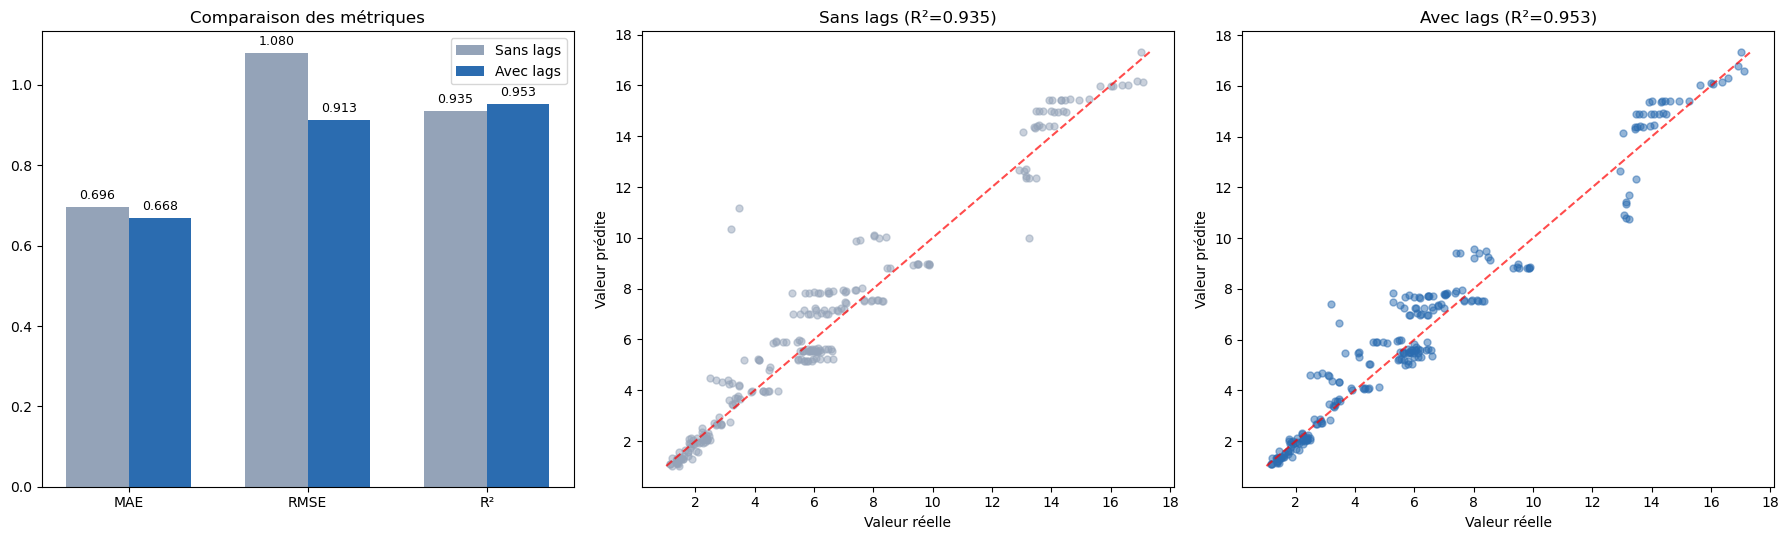

In [35]:
# ============================================================
# COMPARAISON : MODÈLE AVEC vs SANS FEATURES DE LAG
# ============================================================
# Objectif : isoler l'apport réel de l'historique temporel (lags),
# en comparant deux modèles identiques sauf sur ce point.

from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

lag_source_cols = ['gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
                    'oil_production','share_coal_pct','share_renewables_pct']

# --- Version AVEC lags (comme dans le preprocessing principal) ---
df_with_lags = df_annual[['country','year',target] + feature_cols + cat_cols].copy()
df_with_lags['vehicle_ownership'] = df_with_lags.groupby('country')['vehicle_ownership']\
    .transform(lambda x: x.fillna(x.median()))
df_with_lags['vehicle_ownership'] = df_with_lags['vehicle_ownership'].fillna(df_with_lags['vehicle_ownership'].median())

for lag in [1, 2, 5]:
    for col in lag_source_cols:
        df_with_lags[f'{col}_lag{lag}'] = df_with_lags.groupby('country')[col].shift(lag)
for col in lag_source_cols:
    df_with_lags[f'{col}_ma5'] = df_with_lags.groupby('country')[col]\
        .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))

df_with_lags = df_with_lags.dropna().reset_index(drop=True)

# --- Version SANS lags : on garde EXACTEMENT les mêmes lignes (mêmes pays/années) ---
# pour une comparaison équitable, mais sans les colonnes de lag/moyenne mobile
valid_index = df_with_lags[['country','year']]
df_without_lags = df_annual[['country','year',target] + feature_cols + cat_cols]\
    .merge(valid_index, on=['country','year'], how='inner').reset_index(drop=True)

print("Avec lags :", df_with_lags.shape)
print("Sans lags :", df_without_lags.shape)

# --- Fonction pour construire X_train/X_test/y_train/y_test, réutilisable pour les deux versions ---
def build_split(df_m):
    num_cols = [c for c in df_m.columns if c not in ['country','year',target]+cat_cols]
    train = df_m[df_m['year'] <= 2016].copy()
    test = df_m[df_m['year'] > 2016].copy()
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    enc.fit(train[cat_cols])
    train_cat = pd.DataFrame(enc.transform(train[cat_cols]), columns=enc.get_feature_names_out(cat_cols), index=train.index)
    test_cat = pd.DataFrame(enc.transform(test[cat_cols]), columns=enc.get_feature_names_out(cat_cols), index=test.index)
    X_train = pd.concat([train[num_cols], train_cat], axis=1)
    X_test = pd.concat([test[num_cols], test_cat], axis=1)
    return X_train, X_test, train[target], test[target]

def evaluate(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"=== {name} ===")
    print(f"Nb features: {X_train.shape[1]}")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}\n")
    return {'name': name, 'mae': mae, 'rmse': rmse, 'r2': r2}, pred

X_train_lag, X_test_lag, y_train_lag, y_test_lag = build_split(df_with_lags)
X_train_nolag, X_test_nolag, y_train_nolag, y_test_nolag = build_split(df_without_lags)

# Mêmes hyperparamètres pour les deux, pour isoler l'effet des lags uniquement
rf_lag = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf_nolag = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)

res_lag, pred_lag = evaluate(rf_lag, X_train_lag, X_test_lag, y_train_lag, y_test_lag, "AVEC lags")
res_nolag, pred_nolag = evaluate(rf_nolag, X_train_nolag, X_test_nolag, y_train_nolag, y_test_nolag, "SANS lags")

# ============================================================
# GRAPHIQUE COMPARATIF
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- 1. Barres comparatives des métriques ---
metrics = ['mae', 'rmse', 'r2']
labels = ['MAE', 'RMSE', 'R²']
x = np.arange(len(metrics))
width = 0.35

vals_nolag = [res_nolag[m] for m in metrics]
vals_lag = [res_lag[m] for m in metrics]

ax = axes[0]
ax.bar(x - width/2, vals_nolag, width, label='Sans lags', color='#94a3b8')
ax.bar(x + width/2, vals_lag, width, label='Avec lags', color='#2b6cb0')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Comparaison des métriques')
ax.legend()
for i, (v1, v2) in enumerate(zip(vals_nolag, vals_lag)):
    ax.text(i - width/2, v1 + 0.02, f"{v1:.3f}", ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 0.02, f"{v2:.3f}", ha='center', fontsize=9)

# --- 2. Prédictions vs réalité, SANS lags ---
lims = [min(y_test_nolag.min(), pred_nolag.min()), max(y_test_nolag.max(), pred_nolag.max())]
axes[1].scatter(y_test_nolag, pred_nolag, alpha=0.5, s=25, color='#94a3b8')
axes[1].plot(lims, lims, 'r--', alpha=0.7)
axes[1].set_xlabel('Valeur réelle')
axes[1].set_ylabel('Valeur prédite')
axes[1].set_title(f"Sans lags (R²={res_nolag['r2']:.3f})")

# --- 3. Prédictions vs réalité, AVEC lags ---
axes[2].scatter(y_test_lag, pred_lag, alpha=0.5, s=25, color='#2b6cb0')
axes[2].plot(lims, lims, 'r--', alpha=0.7)
axes[2].set_xlabel('Valeur réelle')
axes[2].set_ylabel('Valeur prédite')
axes[2].set_title(f"Avec lags (R²={res_lag['r2']:.3f})")

plt.tight_layout()
plt.show()

Analyse des erreurs du modèle

Jusqu'ici on a mesuré la performance globale (MAE, R²), mais un score moyen peut cacher des
erreurs très inégalement réparties. On regarde ici **où précisément** le modèle se trompe :
par pays, par année, et si les erreurs sont aléatoires ou suivent un biais systématique
(surestimation/sous-estimation récurrente sur certains pays).

=== Statistiques globales des erreurs ===
count    240.000000
mean       0.667789
std        0.623385
min        0.004957
25%        0.196067
50%        0.490824
75%        0.960564
max        4.229649
Name: abs_error, dtype: float64

=== Top 15 pires prédictions (erreur absolue) ===
country  year  y_true    y_pred     error  abs_error
 France  2024    3.19  7.419649  4.229649   4.229649
 France  2023    3.48  6.636434  3.156434   3.156434
 Poland  2024    5.27  7.822491  2.552491   2.552491
 Russia  2018   13.24 10.757602 -2.482398   2.482398
 Russia  2019   13.14 10.796952 -2.343048   2.343048
 Norway  2024    5.29  7.489711  2.199711   2.199711
 Russia  2020   13.08 10.913377 -2.166623   2.166623
 Sweden  2024    2.48  4.591506  2.111506   2.111506
Germany  2023    7.40  9.422124  2.022124   2.022124
 Poland  2021    5.70  7.691829  1.991829   1.991829
 Poland  2023    5.83  7.748282  1.918282   1.918282
 Sweden  2022    2.71  4.607048  1.897048   1.897048
 Norway  2023    5.52  7.3

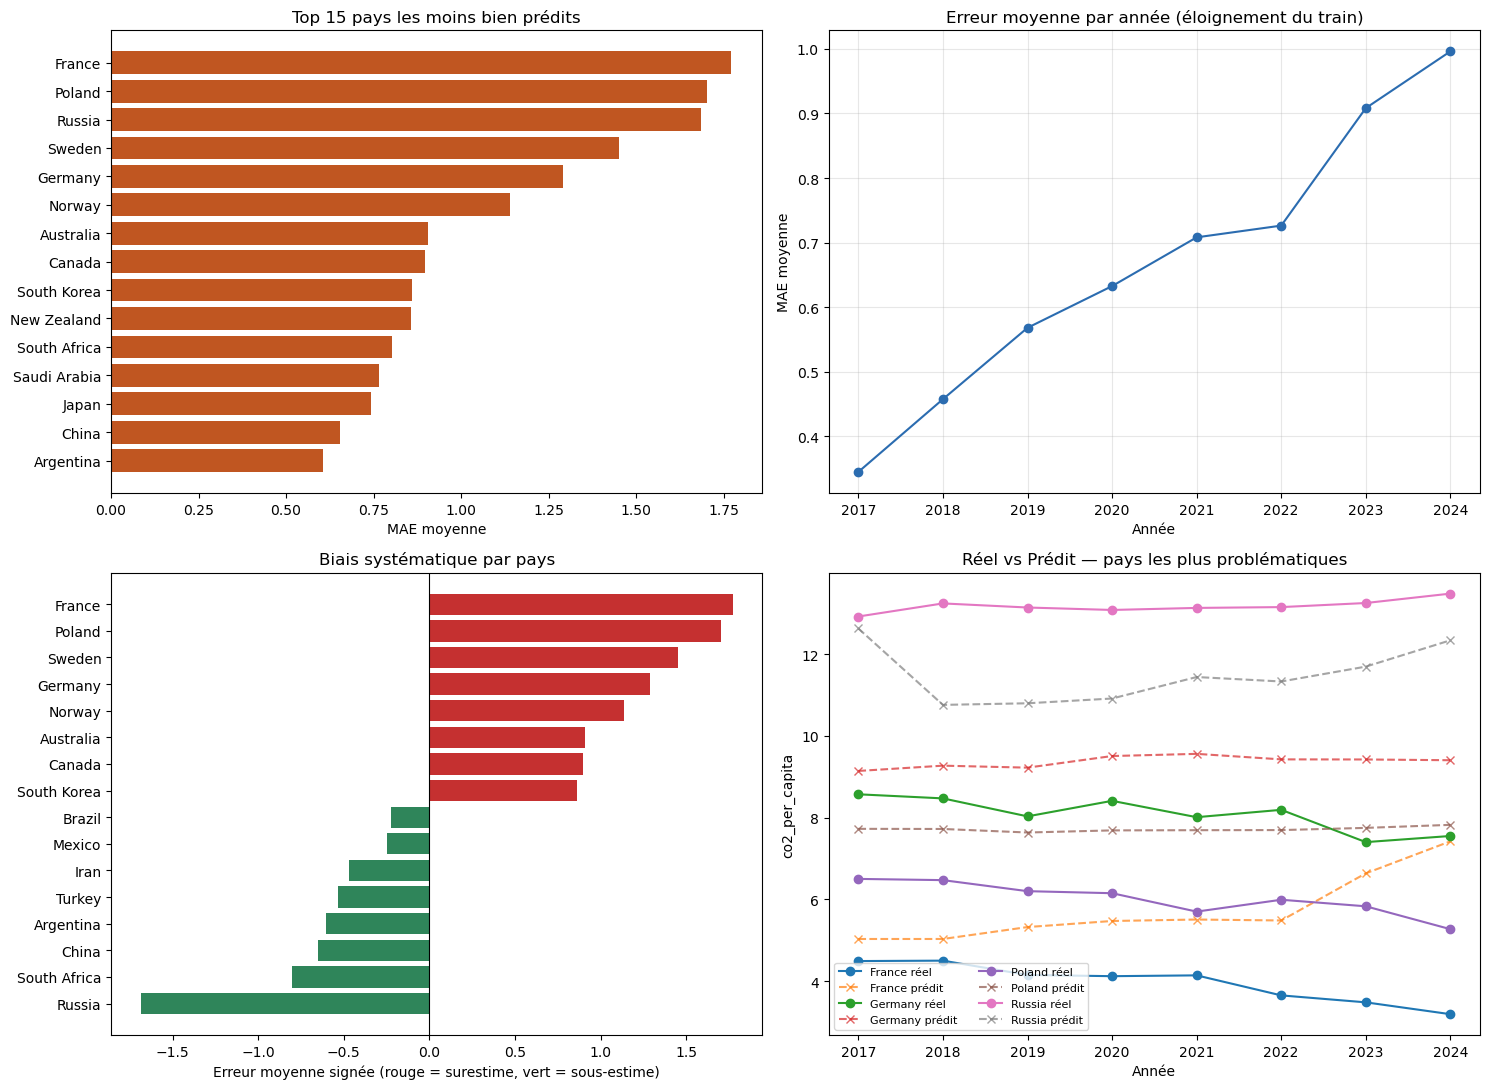

In [36]:
# ============================================================
# ANALYSE DES ERREURS DU MODÈLE
# ============================================================
# Métadonnées (country, year) alignées avec X_test, utiles pour l'analyse des erreurs plus tard
test_meta = test[['country', 'year']]

# On récupère les prédictions du modèle Random Forest "avec lags" (déjà entraîné plus haut)
pred = rf.predict(X_test)

# test_meta contient 'country' et 'year' alignés avec X_test (défini dans le preprocessing)
results = test_meta.reset_index(drop=True).copy()
results['y_true'] = y_test.values
results['y_pred'] = pred
results['error'] = results['y_pred'] - results['y_true']       # signé : positif = surestime, négatif = sous-estime
results['abs_error'] = results['error'].abs()                    # erreur absolue, pour classer les pires cas

print("=== Statistiques globales des erreurs ===")
print(results['abs_error'].describe())
print()
print("=== Top 15 pires prédictions (erreur absolue) ===")
print(results.sort_values('abs_error', ascending=False).head(15)
      [['country','year','y_true','y_pred','error','abs_error']].to_string(index=False))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15,11))

# --- 1. MAE par pays (les 15 moins bien prédits) ---
mae_by_country = results.groupby('country')['abs_error'].mean().sort_values(ascending=False).head(15)
axes[0,0].barh(mae_by_country.index[::-1], mae_by_country.values[::-1], color='#c05621')
axes[0,0].set_xlabel('MAE moyenne')
axes[0,0].set_title('Top 15 pays les moins bien prédits')

# --- 2. MAE par année (est-ce que l'erreur augmente avec l'éloignement du train ?) ---
mae_by_year = results.groupby('year')['abs_error'].mean()
axes[0,1].plot(mae_by_year.index, mae_by_year.values, marker='o', color='#2b6cb0')
axes[0,1].set_xlabel('Année')
axes[0,1].set_ylabel('MAE moyenne')
axes[0,1].set_title('Erreur moyenne par année (éloignement du train)')
axes[0,1].grid(alpha=0.3)

# --- 3. Biais systématique : erreur SIGNÉE moyenne par pays ---
# (contrairement à l'erreur absolue, ça révèle si le modèle sur- ou sous-estime de façon récurrente)
bias_by_country = results.groupby('country')['error'].mean().sort_values()
top_bias = pd.concat([bias_by_country.head(8), bias_by_country.tail(8)])
colors = ['#2f855a' if v < 0 else '#c53030' for v in top_bias.values]  # vert=sous-estime, rouge=surestime
axes[1,0].barh(top_bias.index, top_bias.values, color=colors)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_xlabel('Erreur moyenne signée (rouge = surestime, vert = sous-estime)')
axes[1,0].set_title('Biais systématique par pays')

# --- 4. Zoom sur les pays les plus problématiques : réel vs prédit dans le temps ---
for c in ['France','Germany','Poland','Russia']:
    sub = results[results['country']==c].sort_values('year')
    axes[1,1].plot(sub['year'], sub['y_true'], marker='o', label=f'{c} réel', linestyle='-')

    axes[1,1].plot(sub['year'], sub['y_pred'], marker='x', label=f'{c} prédit', linestyle='--', alpha=0.7)
axes[1,1].set_xlabel('Année')
axes[1,1].set_ylabel('co2_per_capita')
axes[1,1].set_title('Réel vs Prédit — pays les plus problématiques')
axes[1,1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

### Interprétation

**1. L'erreur augmente avec l'éloignement temporel** (graphique en haut à droite) : le modèle se
trompe presque 3x plus en 2024 (MAE≈1.0) qu'en 2017 (MAE≈0.35). Logique : plus on projette loin
dans le futur par rapport à la période d'entraînement (1995-2016), plus l'incertitude grandit.

**2. Un biais directionnel clair, pas juste du bruit aléatoire** (graphiques du bas) : le modèle
**surestime systématiquement** un groupe de pays riches/développés (France, Pologne, Suède,
Allemagne, Norvège, Australie, Canada, Corée du Sud) et **sous-estime** un groupe différent
(Russie, Afrique du Sud, Chine, Argentine, Turquie, Iran, Mexique, Brésil).

**3. Explication du biais** (graphique en bas à droite) : la France et l'Allemagne montrent une
**baisse réelle rapide** de leur `co2_per_capita` sur 2017-2024 (transition énergétique
européenne, accélérée après 2020), alors que le modèle **prédit une quasi-stagnation**. Le
Random Forest, entraîné sur 1995-2016, n'a pas appris qu'un pays peut décarboner rapidement — il
extrapole mal une **rupture de tendance récente**, contrairement à ce qu'il ferait pour une
évolution progressive comme celle apprise dans les données d'entraînement.

**Conclusion à retenir pour la discussion du rapport** : l'analyse des résidus révèle un biais
directionnel systématique plutôt qu'une erreur aléatoire. Le modèle peine à extrapoler des
ruptures de tendance survenues après la période d'entraînement — une limite inhérente aux
modèles à base d'arbres (Random Forest) pour la prédiction temporelle au-delà de la distribution
apprise, contrairement à des modèles de séries temporelles qui capteraient mieux ce type de
changement de régime.

**AJOUTER UNE VARIABLE : BORD POLITIQUE**

In [37]:
df_annual = df.drop_duplicates(subset=['country','year'], keep='first')

In [38]:
# ============================================================
# CONSTRUCTION DE LA VARIABLE "ORIENTATION POLITIQUE" (ParlGov)
# ============================================================
import pandas as pd

# --- 1. Charger la table des cabinets ParlGov ---
df_cabinet = pd.read_csv("view_cabinet.csv")
df_cabinet['start_date'] = pd.to_datetime(df_cabinet['start_date'])

# On ne garde que le parti du Premier ministre = le "parti dominant" de chaque gouvernement
df_pm = df_cabinet[df_cabinet['prime_minister'] == 1].copy()
df_pm = df_pm.sort_values(['country_name', 'start_date'])
df_pm = df_pm.drop_duplicates(subset=['country_name', 'cabinet_id'], keep='first')

# --- 2. Construire le mapping pays/année ---
# Pour chaque année, on cherche quel gouvernement était en place au milieu de l'année (1er juillet)
# -> évite qu'un changement de gouvernement en fin d'année ne fausse artificiellement l'attribution
years = list(range(1990, 2025))
records = []

for country, group in df_pm.groupby('country_name'):
    group = group.sort_values('start_date').reset_index(drop=True)
    for year in years:
        cutoff = pd.Timestamp(f'{year}-07-01')
        valid = group[group['start_date'] <= cutoff]
        if len(valid) == 0:
            continue  # pas encore de gouvernement enregistré à cette date
        current_gov = valid.iloc[-1]
        records.append({
            'country': country,
            'year': year,
            'left_right': current_gov['left_right'],

        })

df_political = pd.DataFrame(records)

# --- 3. Fusionner avec le dataset climat ---
df_annual = df_annual.merge(
    df_political[['country', 'year', 'left_right']],
    on=['country', 'year'], how='left'
)

coverage = df_annual['left_right'].notna().mean() * 100
print(f"Couverture globale : {coverage:.1f}% des lignes ont un score politique")
print()
print("Pays couverts par ParlGov :")
print(df_annual.groupby('country')['left_right'].apply(lambda x: x.notna().mean()*100)
      .loc[lambda x: x > 0].index.tolist())


Couverture globale : 36.7% des lignes ont un score politique

Pays couverts par ParlGov :
['Australia', 'Canada', 'France', 'Germany', 'Japan', 'New Zealand', 'Norway', 'Poland', 'Sweden', 'Turkey', 'United Kingdom']


In [39]:
df_annual.head()

,country,iso_code,year,month,continent,income_group,latitude,longitude,latitude_band,climate_zone,...,industrial_share_gdp,agriculture_share_gdp,vehicle_ownership,radiative_forcing,temp_change_from_co2,climate_risk_score,warming_category,renewable_transition_stage,emission_intensity_level,left_right
0,Argentina,ARG,1990,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,23,8,264.0,2.000,0.29,12.2,Normal,Low,Medium,NaN
1,Argentina,ARG,1991,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,23,8,276.0,2.059,0.27,17.7,Normal,Low,Medium,NaN
2,Argentina,ARG,1992,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,23,8,278.0,2.118,0.17,10.5,Normal,Low,Medium,NaN
3,Argentina,ARG,1993,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,23,8,284.0,2.177,0.17,9.3,Normal,Low,Medium,NaN
4,Argentina,ARG,1994,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,23,8,275.0,2.236,0.22,15.6,Normal,Low,Medium,NaN


In [40]:
##vérifier que ce soit ok 

print(df_annual[df_annual['country']=='France'][['year','left_right']].drop_duplicates().to_string(index=False))

 year  left_right
 1990      3.2493
 1991      3.2493
 1992      3.2493
 1993      7.4997
 1994      7.4997
 1995      7.4997
 1996      7.4997
 1997      3.2493
 1998      3.2493
 1999      3.2493
 2000      3.2493
 2001      3.2493
 2002      7.4997
 2003      7.4997
 2004      7.4997
 2005      7.4997
 2006      7.4997
 2007      7.4997
 2008      7.4997
 2009      7.4997
 2010      7.4997
 2011      7.4997
 2012      3.2493
 2013      3.2493
 2014      3.2493
 2015      3.2493
 2016      3.2493
 2017      7.4997
 2018      7.4997
 2019      7.4997
 2020      7.4997
 2021      6.0000
 2022      6.0000
 2023      6.0000
 2024      6.0000


In [41]:
# ============================================================
# AJOUT DES LAGS POUR left_right
# ============================================================
import pandas as pd

# On recrée df_pol à partir de df_annual (déjà en mémoire dans ton notebook),
# au lieu de charger un fichier qui n'existe pas chez toi
covered = ['Australia','Canada','France','Germany','Japan','New Zealand',
           'Norway','Poland','Sweden','Turkey','United Kingdom']

df_pol = df_annual[df_annual['country'].isin(covered)].copy()
df_pol = df_pol.dropna(subset=['left_right'])
df_pol = df_pol.sort_values(['country','year']).reset_index(drop=True)

# Lags de l'orientation politique (1, 2, 5 ans), comme pour les autres variables
for lag in [1, 2, 5]:
    df_pol[f'left_right_lag{lag}'] = df_pol.groupby('country')['left_right'].shift(lag)

# Moyenne mobile 5 ans : "tendance politique récente" plutôt qu'un instant précis
df_pol['left_right_ma5'] = df_pol.groupby('country')['left_right']\
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))

print(df_pol[df_pol['country']=='France']
      [['year','left_right','left_right_lag1','left_right_lag2','left_right_lag5','left_right_ma5']]
      .to_string(index=False))

 year  left_right  left_right_lag1  left_right_lag2  left_right_lag5  left_right_ma5
 1990      3.2493              NaN              NaN              NaN             NaN
 1991      3.2493           3.2493              NaN              NaN         3.24930
 1992      3.2493           3.2493           3.2493              NaN         3.24930
 1993      7.4997           3.2493           3.2493              NaN         3.24930
 1994      7.4997           7.4997           3.2493              NaN         4.31190
 1995      7.4997           7.4997           7.4997           3.2493         4.94946
 1996      7.4997           7.4997           7.4997           3.2493         5.79954
 1997      3.2493           7.4997           7.4997           3.2493         6.64962
 1998      3.2493           3.2493           7.4997           7.4997         6.64962
 1999      3.2493           3.2493           3.2493           7.4997         5.79954
 2000      3.2493           3.2493           3.2493           7.4

In [42]:
# ============================================================
# COMPLÉTER left_right AVEC LA SOURCE ALTERNATIVE (Global Leader Ideology)
# POUR LES 10 DÉMOCRATIES NON COUVERTES PAR PARLGOV
# ============================================================
import pandas as pd

df_ideo = pd.read_csv("identifying_ideologues.tab", sep='\t')

# hog_ideology_num_full : 0=rightist, 1=leftist, 2=centrist, 3=none, 4=no information
# On ne garde que les vraies catégories idéologiques (0,1,2), le reste devient NaN
# Puis on convertit sur une échelle 0-10 comparable à ParlGov : gauche=2.5, centre=5, droite=7.5
mapping_scale = {0: 7.5, 1: 2.5, 2: 5.0}
df_ideo['left_right_alt'] = df_ideo['hog_ideology_num_full'].map(mapping_scale)

# Harmoniser le nom des USA avec le dataset climat
df_ideo['country_name'] = df_ideo['country_name'].replace({'United States of America': 'United States'})

# Les 10 démocraties non couvertes par ParlGov
democraties_manquantes = ['Argentina', 'Brazil', 'India', 'Indonesia', 'Kenya', 'Mexico',
                            'Nigeria', 'South Africa', 'South Korea', 'United States']

df_ideo_subset = df_ideo[df_ideo['country_name'].isin(democraties_manquantes)].copy()
df_ideo_subset = df_ideo_subset[['country_name','year','left_right_alt']].rename(columns={'country_name':'country'})
df_ideo_subset = df_ideo_subset[(df_ideo_subset['year']>=1990) & (df_ideo_subset['year']<=2024)]

# --- Fusionner avec df_annual, en complétant SEULEMENT les NaN de left_right existant ---
df_annual = df_annual.merge(df_ideo_subset, on=['country','year'], how='left')

# combine_first : garde left_right (ParlGov) quand il existe, sinon utilise left_right_alt
df_annual['left_right'] = df_annual['left_right'].combine_first(df_annual['left_right_alt'])
df_annual = df_annual.drop(columns=['left_right_alt'])


coverage = df_annual['left_right'].notna().mean() * 100
print(f"Nouvelle couverture globale : {coverage:.1f}%")
print()
print("Couverture par pays :")
print(df_annual.groupby('country')['left_right'].apply(lambda x: x.notna().mean()*100).sort_values(ascending=False))

Nouvelle couverture globale : 65.6%

Couverture par pays :
country
Australia         100.000000
United Kingdom    100.000000
Canada            100.000000
Turkey            100.000000
Sweden            100.000000
France            100.000000
Germany           100.000000
Poland            100.000000
Norway            100.000000
Japan             100.000000
New Zealand       100.000000
Argentina          88.571429
United States      88.571429
South Korea        88.571429
South Africa       88.571429
Mexico             88.571429
Kenya              88.571429
Indonesia          88.571429
India              88.571429
Brazil             88.571429
Nigeria            71.428571
Iran                0.000000
Pakistan            0.000000
Russia              0.000000
Saudi Arabia        0.000000
Ethiopia            0.000000
Egypt               0.000000
China               0.000000
Bangladesh          0.000000
Vietnam             0.000000
Name: left_right, dtype: float64


In [43]:
# ============================================================
# COMPLÉTER LES 9 RÉGIMES NON-DÉMOCRATIQUES AVEC V-DEM (regime_type)
# ============================================================
import pandas as pd

url = "https://ourworldindata.org/grapher/political-regime.csv?v=1&csvType=full&useColumnShortNames=false"
df_regime = pd.read_csv(url, storage_options={'User-Agent': 'Mozilla/5.0'})

print(df_regime.columns.tolist())
print(df_regime.head())

['Entity', 'Code', 'Year', 'Political regime']
        Entity Code  Year  Political regime
0  Afghanistan  AFG  1789                 0
1  Afghanistan  AFG  1790                 0
2  Afghanistan  AFG  1791                 0
3  Afghanistan  AFG  1792                 0
4  Afghanistan  AFG  1793                 0


In [44]:
# ============================================================
# COMPLÉTER LES RÉGIMES NON-DÉMOCRATIQUES AVEC V-DEM (regime_type)
# ============================================================
import pandas as pd

url = "https://ourworldindata.org/grapher/political-regime.csv?v=1&csvType=full&useColumnShortNames=false"
df_regime = pd.read_csv(url, storage_options={'User-Agent': 'Mozilla/5.0'})

# Renommer proprement
df_regime = df_regime.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Political regime': 'regime_score'
})

# 0=Autocratie fermée, 1=Autocratie électorale, 2=Démocratie électorale, 3=Démocratie libérale
regime_labels = {0: 'Closed autocracy', 1: 'Electoral autocracy',
                 2: 'Electoral democracy', 3: 'Liberal democracy'}
df_regime['regime_type'] = df_regime['regime_score'].map(regime_labels)

df_regime = df_regime[['country','year','regime_type']]

# --- Vérifier les noms de pays avant de fusionner ---
pays_climat = set(df_annual['country'].unique())
pays_vdem = set(df_regime['country'].unique())
print("Pays climat non trouvés dans V-Dem :", pays_climat - pays_vdem)

# --- Fusionner avec df_annual ---
df_annual = df_annual.merge(df_regime, on=['country','year'], how='left')

print(f"\nCouverture regime_type : {df_annual['regime_type'].notna().mean()*100:.1f}%")
print(df_annual.groupby('country')['regime_type'].first())

Pays climat non trouvés dans V-Dem : set()

Couverture regime_type : 99.8%
country
Argentina         Electoral democracy
Australia           Liberal democracy
Bangladesh        Electoral autocracy
Brazil            Electoral democracy
Canada              Liberal democracy
China                Closed autocracy
Egypt             Electoral autocracy
Ethiopia             Closed autocracy
France              Liberal democracy
Germany             Liberal democracy
India             Electoral democracy
Indonesia         Electoral autocracy
Iran              Electoral autocracy
Japan               Liberal democracy
Kenya             Electoral autocracy
Mexico            Electoral autocracy
New Zealand         Liberal democracy
Nigeria              Closed autocracy
Norway              Liberal democracy
Pakistan          Electoral autocracy
Poland            Electoral democracy
Russia               Closed autocracy
Saudi Arabia         Closed autocracy
South Africa         Closed autocracy
South

In [45]:
for c in ['South Africa', 'Nigeria', 'Russia']:
    print(f"\n=== {c} ===")
    print(df_annual[df_annual['country']==c][['year','regime_type']].drop_duplicates().to_string(index=False))


=== South Africa ===
 year         regime_type
 1990    Closed autocracy
 1991    Closed autocracy
 1992    Closed autocracy
 1993    Closed autocracy
 1994 Electoral autocracy
 1995 Electoral democracy
 1996   Liberal democracy
 1997   Liberal democracy
 1998   Liberal democracy
 1999   Liberal democracy
 2000   Liberal democracy
 2001   Liberal democracy
 2002   Liberal democracy
 2003   Liberal democracy
 2004   Liberal democracy
 2005   Liberal democracy
 2006   Liberal democracy
 2007   Liberal democracy
 2008   Liberal democracy
 2009   Liberal democracy
 2010   Liberal democracy
 2011   Liberal democracy
 2012   Liberal democracy
 2013 Electoral democracy
 2014 Electoral democracy
 2015 Electoral democracy
 2016 Electoral democracy
 2017 Electoral democracy
 2018 Electoral democracy
 2019 Electoral democracy
 2020 Electoral democracy
 2021 Electoral democracy
 2022 Electoral democracy
 2023 Electoral democracy
 2024 Electoral democracy

=== Nigeria ===
 year         regime_type

In [46]:
# ============================================================
# INTÉGRATION DES VARIABLES POLITIQUES DANS LE PIPELINE PRINCIPAL (30 PAYS)
# ============================================================
import pandas as pd
import numpy as np

# --- 1. Indicateur : a-t-on un score left_right disponible pour cette ligne ? ---
# Utile pour que le modèle distingue "pas de score car régime non-démocratique"
# d'une vraie valeur centriste (5.0)
df_annual['has_left_right'] = df_annual['left_right'].notna().astype(int)

# --- 2. Imputer les NaN de left_right avec une valeur neutre (5.0 = centre) ---
# On ne peut pas laisser de NaN pour un Random Forest classique (sklearn ne gère pas nativement)
# 5.0 est un choix arbitraire mais documenté : combiné à has_left_right, le modèle peut
# apprendre à traiter différemment "vraiment centriste" vs "info manquante"
df_annual['left_right'] = df_annual['left_right'].fillna(5.0)

# --- 3. regime_type : combler les ~0.2% de NaN restants avec une catégorie dédiée ---
df_annual['regime_type'] = df_annual['regime_type'].fillna('Unknown')

# --- 4. Ajouter left_right à la liste des features numériques + ses lags ---
# Nouvelles listes (suffixe 2) : on ne modifie pas les listes d'origine, pour pouvoir réexécuter sans doublons
feature_cols2 = feature_cols + ['left_right', 'has_left_right']
cat_cols2 = cat_cols + ['regime_type']

# Ajouter left_right aux variables qui reçoivent des lags (comme gdp_per_capita, etc.)
lag_source_cols2 = lag_source_cols + ['left_right']

print("Nouvelles feature_cols:", feature_cols2)
print("Nouvelles cat_cols:", cat_cols2)

Nouvelles feature_cols: ['gdp_per_capita_usd', 'urbanization_rate', 'vehicle_ownership', 'agriculture_share_gdp', 'industrial_share_gdp', 'oil_production', 'share_coal_pct', 'share_renewables_pct', 'forest_cover_pct', 'population_density', 'left_right', 'has_left_right']
Nouvelles cat_cols: ['income_group', 'continent', 'regime_type']


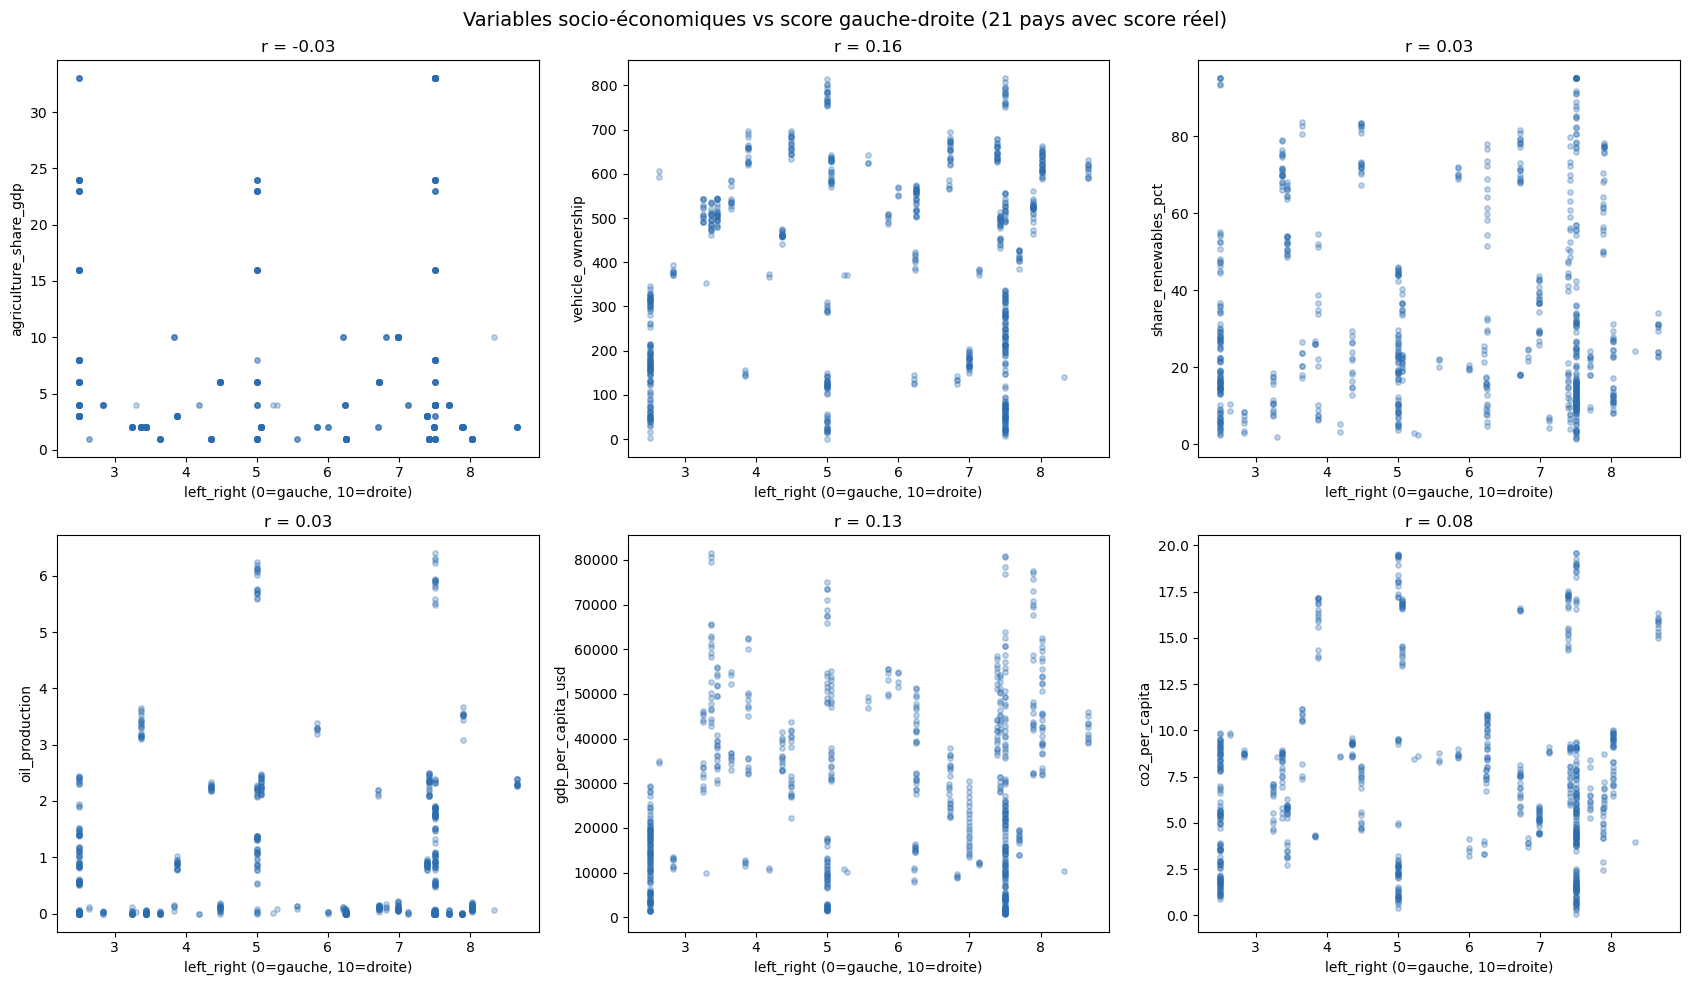

In [47]:
vars_to_plot = ['agriculture_share_gdp', 'vehicle_ownership', 'share_renewables_pct',
                'oil_production', 'gdp_per_capita_usd', 'co2_per_capita']

# Utiliser seulement les lignes où left_right est un vrai score (pas imputé à 5.0)
df_pol = df_annual[df_annual['has_left_right']==1]

fig, axes = plt.subplots(2, 3, figsize=(17,10))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_pol['left_right'], df_pol[var], alpha=0.3, s=15, color='#2b6cb0')
    corr = df_pol['left_right'].corr(df_pol[var])
    ax.set_xlabel('left_right (0=gauche, 10=droite)')
    ax.set_ylabel(var)
    ax.set_title(f"r = {corr:.2f}")

plt.suptitle("Variables socio-économiques vs score gauche-droite (21 pays avec score réel)", fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
### suite pré-processing pour le modèle final (avec features politiques) ###

# On garde country/year à ce stade : nécessaires pour les lags (groupby) et le split temporel
# Elles seront explicitement retirées de X_train/X_test plus bas
df_model2 = df_annual[['country','year',target] + feature_cols2 + cat_cols2].copy()

# --- Gestion des valeurs manquantes ---
# vehicle_ownership a quelques NaN : on impute par la médiane du pays lui-même
# (plus logique que la médiane globale, qui mélangerait des pays très différents)
df_model2['vehicle_ownership'] = df_model2.groupby('country')['vehicle_ownership']\
    .transform(lambda x: x.fillna(x.median()))
df_model2['vehicle_ownership'] = df_model2['vehicle_ownership'].fillna(df_model2['vehicle_ownership'].median())

# --- Création des features de lag (historique) ---
# Pour chaque variable clé, on ajoute sa valeur il y a 1, 2 et 5 ans
# groupby('country') est essentiel : on ne veut jamais mélanger l'historique
# d'un pays avec celui d'un autre pays

for lag in [1, 2, 5]:
    for col in lag_source_cols2:
        df_model2[f'{col}_lag{lag}'] = df_model2.groupby('country')[col].shift(lag)

# --- Moyenne mobile 5 ans (tendance récente lissée) ---
# .shift(1) pour ne pas inclure l'année actuelle dans sa propre moyenne (fuite de données)
for col in lag_source_cols2:
    df_model2[f'{col}_ma5'] = df_model2.groupby('country')[col]\
        .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))

# Les premières années de chaque pays n'ont pas assez d'historique pour le lag5 -> NaN -> on les retire
df_model2 = df_model2.dropna().reset_index(drop=True)

# --- Split train/test temporel ---
# Train = passé (1995-2016), Test = futur jamais vu (2017-2024)
# Volontairement PAS aléatoire : on veut tester la capacité à prédire le futur, pas mémoriser
train = df_model2[df_model2['year'] <= 2016].copy()
test  = df_model2[df_model2['year'] > 2016].copy()

# --- Encodage des variables catégorielles (one-hot) ---
# Le OneHotEncoder est "fit" uniquement sur le train, pour ne jamais laisser
# d'information du test influencer le preprocessing (fuite de données)
num_cols = [c for c in df_model2.columns if c not in ['country','year',target]+cat_cols2]

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(train[cat_cols2])

train_cat = pd.DataFrame(enc.transform(train[cat_cols2]),
                          columns=enc.get_feature_names_out(cat_cols2), index=train.index)
test_cat = pd.DataFrame(enc.transform(test[cat_cols2]),
                         columns=enc.get_feature_names_out(cat_cols2), index=test.index)

# country et year sont ici volontairement exclues de X_train/X_test :
# ce ne sont pas des features numériques exploitables telles quelles par le modèle
X_train2 = pd.concat([train[num_cols], train_cat], axis=1)
X_test2  = pd.concat([test[num_cols], test_cat], axis=1)
y_train2 = train[target]
y_test2  = test[target]

print(f"Train: {X_train2.shape[0]} lignes, {X_train2.shape[1]} features")
print(f"Test:  {X_test2.shape[0]} lignes")

df_model2.head()

Train: 660 lignes, 55 features
Test:  240 lignes


,country,year,co2_per_capita,gdp_per_capita_usd,urbanization_rate,vehicle_ownership,agriculture_share_gdp,industrial_share_gdp,oil_production,share_coal_pct,...,share_coal_pct_lag5,share_renewables_pct_lag5,left_right_lag5,gdp_per_capita_usd_ma5,urbanization_rate_ma5,vehicle_ownership_ma5,oil_production_ma5,share_coal_pct_ma5,share_renewables_pct_ma5,left_right_ma5
0,Argentina,1995,4.23,11130.0,90.9,282.0,8,23,0.55,1.5,...,2.3,9.4,7.5,9605.6,90.68,275.4,0.526,2.16,9.06,7.5
1,Argentina,1996,4.50,11545.0,92.5,282.0,8,23,0.48,1.2,...,2.5,8.0,7.5,10081.8,91.06,279.0,0.534,2.00,9.36,7.5
2,Argentina,1997,4.44,11890.0,93.1,265.0,8,23,0.55,1.9,...,1.7,9.7,7.5,10506.6,91.58,280.2,0.518,1.74,9.98,7.5
3,Argentina,1998,4.43,12338.0,93.3,302.0,8,23,0.50,0.1,...,1.7,8.6,7.5,10976.6,91.82,277.6,0.522,1.78,9.76,7.5
4,Argentina,1999,5.02,13053.0,92.4,287.0,8,23,0.52,0.4,...,2.6,9.6,7.5,11439.6,92.40,281.2,0.518,1.46,10.28,7.5


In [49]:

# --- Modèle 1 : Régression linéaire (baseline simple/interprétable) ---
lr = LinearRegression()
lr.fit(X_train2, y_train2)
pred_lr = lr.predict(X_test2)

# --- Modèle 2 : Random Forest (capture non-linéarités et interactions) ---
rf = RandomForestRegressor(
    n_estimators=300,   # nombre d'arbres
    max_depth=8,        # profondeur max, limite le surapprentissage
    random_state=42,    # reproductibilité
    n_jobs=-1            # utilise tous les coeurs CPU disponibles
)
rf.fit(X_train2, y_train2)
pred_rf = rf.predict(X_test2)

# --- Évaluation ---
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}\n")

evaluate(y_test2, pred_lr, "Régression Linéaire")
evaluate(y_test2, pred_rf, "Random Forest")

joblib.dump({'rf':rf,'lr':lr,'X_train':X_train2,'X_test':X_test2,'y_train':y_train2,'y_test':y_test2,
             'pred_rf':pred_rf,'pred_lr':pred_lr,'test_meta':test[['country','year']]}, 'model_results.pkl')

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- has_left_right
- left_right
- left_right_lag1
- left_right_lag2
- left_right_lag5
- ...


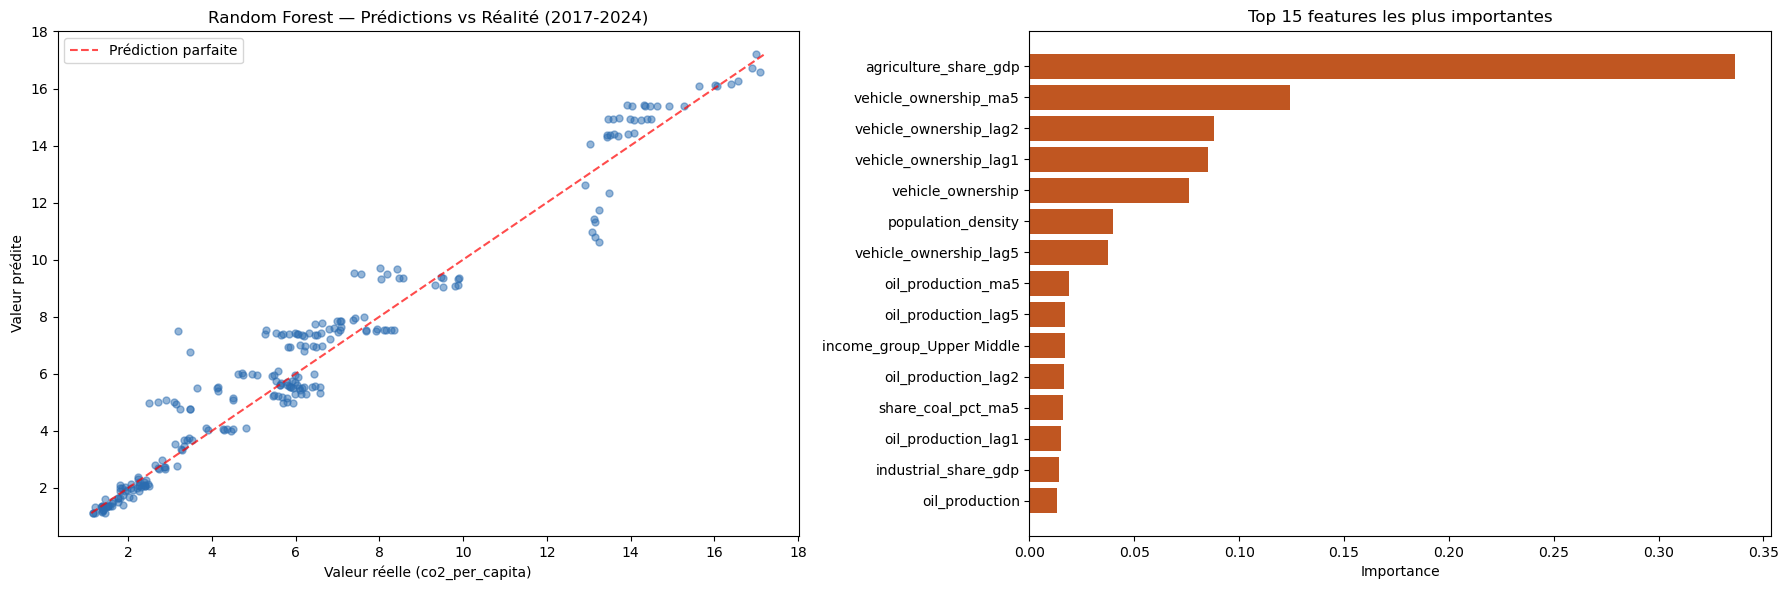

agriculture_share_gdp        0.336669
vehicle_ownership_ma5        0.124354
vehicle_ownership_lag2       0.088162
vehicle_ownership_lag1       0.085326
vehicle_ownership            0.076229
population_density           0.039646
vehicle_ownership_lag5       0.037261
oil_production_ma5           0.018952
oil_production_lag5          0.016905
income_group_Upper Middle    0.016831
oil_production_lag2          0.016646
share_coal_pct_ma5           0.015939
oil_production_lag1          0.014902
industrial_share_gdp         0.014091
oil_production               0.013273
dtype: float64


In [ ]:
# Visualisation : prédictions vs réalité + feature importance (Random Forest baseline)
fig, axes = plt.subplots(1, 2, figsize=(18,6))

axes[0].scatter(y_test2, pred_rf, alpha=0.5, s=25, color='#2b6cb0')
lims = [min(y_test2.min(),pred_rf.min()), max(y_test2.max(),pred_rf.max())]
axes[0].plot(lims, lims, 'r--', alpha=0.7, label='Prédiction parfaite')
axes[0].set_xlabel('Valeur réelle (co2_per_capita)')
axes[0].set_ylabel('Valeur prédite')
axes[0].set_title('Random Forest — Prédictions vs Réalité (2017-2024)')
axes[0].legend()

importances = pd.Series(rf.feature_importances_, index=X_train2.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances.index[::-1], importances.values[::-1], color='#c05621')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 features les plus importantes')

plt.tight_layout()
plt.show()
print(importances)

In [ ]:
###Ca n'a PAS amelioré le modèle 


### RF sur la variation + variables politiques

On reprend le **RF sur la variation depuis la dernière année connue** (meilleur modèle jusqu'ici) et on lui ajoute les variables politiques construites ci-dessus :
- `left_right` à l'année prédite et **son évolution depuis l'ancre** `d_left_right` (le pays a-t-il basculé à gauche ou à droite depuis 2016 ?) ;
- `has_left_right` (score réel disponible ou valeur imputée à 5) ;
- `regime_type` (type de régime V-Dem) en variables indicatrices.

Même protocole que pour le RF sur la variation : comparaison **sans / avec** politique sur la validation (ancre 2012 → 2013-2016), puis test 2017-2024 une seule fois, puis importance par permutation des variables politiques.

⚠️ Cellules à exécuter **après** la partie politique (elles utilisent `df_annual` enrichi de `left_right`, `has_left_right`, `regime_type`) et après la section « RF sur la variation » (`df_model`, `delta_cols`, `delta_features`, `test_keys`).

In [ ]:
# --- Base : données de df_model (mêmes lignes que le RF sur la variation) + variables politiques ---
pol_cols = ['left_right', 'has_left_right', 'regime_type']
base_pol = df_model[['country', 'year', target] + delta_cols].merge(
    df_annual[['country', 'year'] + pol_cols].drop_duplicates(['country', 'year']),
    on=['country', 'year'], how='left')

regime_dummies = pd.get_dummies(base_pol['regime_type'], prefix='regime', dtype=int)
regime_cols = list(regime_dummies.columns)
base_pol = pd.concat([base_pol, regime_dummies], axis=1)
print("Valeurs manquantes :", base_pol[pol_cols].isna().sum().to_dict())
print("Types de régime :", regime_cols)

def make_pairs_pol(anchor_years, target_min, target_max, hmax=8):
    """Même construction que make_pairs, en ajoutant les variables politiques."""
    num = delta_cols + ['left_right']                      # variables dont on calcule l'évolution depuis l'ancre
    b = base_pol[base_pol['year'].isin(anchor_years)][['country', 'year', target] + num]
    t = base_pol[(base_pol['year'] >= target_min) & (base_pol['year'] <= target_max)]
    p = t.merge(b, on='country', suffixes=('', '_b'))
    p['h'] = p['year'] - p['year_b']
    p = p[(p['h'] >= 1) & (p['h'] <= hmax)].copy()
    for f in num:
        p['d_' + f] = p[f] - p[f + '_b']
    p['delta'] = p[target] - p[target + '_b']
    return p

political_features = ['left_right', 'd_left_right', 'has_left_right'] + regime_cols
feature_sets = {
    'RF variation (sans politique)': delta_features,
    'RF variation + politique': delta_features + political_features,
}

# --- Validation : ancre 2012 -> 2013-2016 ---
pp_fit = make_pairs_pol(range(1995, 2012), 1995, 2012)
pp_val = make_pairs_pol([2012], 2013, 2016)
print("\nMAE validation 2013-2016 :")
for name, feats in feature_sets.items():
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
    m.fit(pp_fit[feats], pp_fit['delta'])
    print(f"  {name:32s} {mean_absolute_error(pp_val[target], pp_val[target + '_b'] + m.predict(pp_val[feats])):.3f}")

In [ ]:
# --- Test 2017-2024 depuis l'ancre 2016 (une seule fois) ---
pp_train = make_pairs_pol(range(1995, 2016), 1995, 2016)
pp_test = make_pairs_pol([2016], 2017, 2024)

rf_pol_models, results_pol = {}, []
for name, feats in feature_sets.items():
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
    m.fit(pp_train[feats], pp_train['delta'])
    pp_test['pred'] = pp_test[target + '_b'] + m.predict(pp_test[feats])
    y_pred = test_keys.merge(pp_test[['country', 'year', 'pred']], on=['country', 'year'], how='left')['pred'].values
    results_pol.append(modelresults(y_pred, name))
    rf_pol_models[name] = m

rf_delta_pol = rf_pol_models['RF variation + politique']
results_rf_delta_pol = results_pol[1]
pd.DataFrame(results_pol)

In [ ]:
# --- Importance par permutation (test) : les variables politiques aident-elles ? ---
rng = np.random.default_rng(42)
feats_pol = feature_sets['RF variation + politique']

def pol_test_mae(P):
    return mean_absolute_error(P[target], P[target + '_b'] + rf_delta_pol.predict(P[feats_pol]))

base_mae_pol = pol_test_mae(pp_test)
groups = {
    'Orientation gauche-droite (left_right, d_left_right, has_left_right)': ['left_right', 'd_left_right', 'has_left_right'],
    'Type de régime (regime_type)': regime_cols,
    'PIB/hab (niveau + évolution)': ['gdp_per_capita_usd', 'd_gdp_per_capita_usd'],
    'Motorisation (niveau + évolution)': ['vehicle_ownership', 'd_vehicle_ownership'],
}
rows = []
for name, cols in groups.items():
    inc = []
    for _ in range(10):
        P = pp_test.copy()
        P[cols] = pp_test[cols].values[rng.permutation(len(pp_test))]
        inc.append(pol_test_mae(P) - base_mae_pol)
    rows.append({'groupe de variables': name, 'hausse de la MAE si mélangé': np.mean(inc), 'écart-type': np.std(inc)})

print(f"MAE test du modèle avec politique : {base_mae_pol:.3f}")
pd.DataFrame(rows).sort_values('hausse de la MAE si mélangé', ascending=False).round(4)

Maintenant je veux fait le split train/test par pays, pour tester la capacité du modèle à généraliser sur des pays jamais vus.

### Comparaison des pays selon leur orientation politique moyenne

Pour chaque pays, on **moyenne le score gauche-droite** (`left_right`, 0 = gauche, 10 = droite) sur les années où un **vrai score** existe (`has_left_right == 1`, pas les valeurs imputées à 5), puis on compare les pays entre eux :
1. classement des pays selon leur orientation moyenne ;
2. orientation moyenne vs **niveaux moyens** (CO₂/hab, PIB/hab, part des renouvelables, part du charbon) ;
3. orientation moyenne vs **évolutions** (variation annuelle moyenne du CO₂/hab et de la part des renouvelables), plus proches de la question « la politique influence-t-elle la trajectoire d'un pays ? ».

⚠️ À lire avec prudence : seulement **21 pays** (ceux avec un vrai score), deux sources différentes (ParlGov et Global Leader Ideology, cette dernière en 3 catégories seulement), et une corrélation entre moyennes de pays ne prouve pas un effet causal (les pays riches, nordiques, producteurs de pétrole… diffèrent sur bien d'autres points).

In [68]:
from scipy.stats import pearsonr

annual_unique = df_annual.drop_duplicates(['country', 'year'])

def yearly_trend(g, col):
    """Pente moyenne par an (régression linéaire de la variable sur l'année)."""
    return np.polyfit(g['year'], g[col], 1)[0] if g[col].notna().sum() >= 5 else np.nan

def summarize_countries(rows):
    """Moyennes par pays + évolutions annuelles moyennes (CO2 en %/an, renouvelables en points/an)."""
    out = rows.groupby('country').agg(
        nb_annees=('year', 'nunique'),
        co2_per_capita=('co2_per_capita', 'mean'),
        gdp_per_capita_usd=('gdp_per_capita_usd', 'mean'),
        share_renewables_pct=('share_renewables_pct', 'mean'),
        share_coal_pct=('share_coal_pct', 'mean'),
    )
    for country, g in rows.groupby('country'):
        out.loc[country, 'evol_co2_pct_an'] = 100 * yearly_trend(g, 'co2_per_capita') / g['co2_per_capita'].mean()
        out.loc[country, 'evol_renouv_pts_an'] = yearly_trend(g, 'share_renewables_pct')
    return out

# --- Démocraties : moyennes sur les années avec un vrai score politique ---
pol_real = annual_unique[annual_unique['has_left_right'] == 1]
country_pol = summarize_countries(pol_real)
country_pol.insert(0, 'left_right_moyen', pol_real.groupby('country')['left_right'].mean())
# Source du score : ParlGov (échelle continue) ou Global Leader Ideology (3 catégories)
country_pol['source'] = np.where(country_pol.index.isin(democraties_manquantes),
                                 'Global Leader Ideology', 'ParlGov')
country_pol = country_pol.sort_values('left_right_moyen')

# --- Autocraties : pays sans AUCUN score gauche-droite, moyennes sur toutes les années ---
no_score = annual_unique.groupby('country')['has_left_right'].max()
aut_rows = annual_unique[annual_unique['country'].isin(no_score[no_score == 0].index)]
country_aut = summarize_countries(aut_rows)
country_aut['regime_majoritaire'] = aut_rows.groupby('country')['regime_type'].agg(lambda x: x.mode()[0])

print(f"{len(country_pol)} pays avec un vrai score politique | {len(country_aut)} autocraties sans score")
display(country_aut.round(2))
country_pol.round(2)

21 pays avec un vrai score politique | 9 autocraties sans score


,nb_annees,co2_per_capita,gdp_per_capita_usd,share_renewables_pct,share_coal_pct,evol_co2_pct_an,evol_renouv_pts_an,regime_majoritaire
country,,,,,,,,
Bangladesh,35,0.98,1395.49,12.46,10.97,4.23,0.68,Electoral autocracy
China,35,5.11,10535.40,24.88,67.14,1.40,1.30,Closed autocracy
Egypt,35,2.87,4651.14,17.49,7.74,1.27,0.67,Electoral autocracy
Ethiopia,35,0.80,605.94,93.25,5.77,4.32,0.17,Electoral autocracy
Iran,35,7.02,12611.91,12.37,1.37,1.04,0.70,Electoral autocracy
Pakistan,35,1.48,2327.46,19.46,17.66,2.88,0.70,Electoral autocracy
Russia,35,12.20,16851.49,12.31,16.87,0.58,0.68,Electoral autocracy
Saudi Arabia,35,15.28,25753.00,9.76,0.01,-0.65,0.69,Closed autocracy
Vietnam,35,1.71,3493.60,40.74,26.07,2.53,1.64,Electoral autocracy


,left_right_moyen,nb_annees,co2_per_capita,gdp_per_capita_usd,share_renewables_pct,share_coal_pct,evol_co2_pct_an,evol_renouv_pts_an,source
country,,,,,,,,,
South Africa,3.15,31,8.56,12437.45,9.14,71.13,0.88,0.68,Global Leader Ideology
Brazil,4.52,31,3.24,15349.00,48.32,5.68,2.03,0.52,Global Leader Ideology
Nigeria,4.60,25,1.27,3424.92,27.29,6.17,3.48,0.69,Global Leader Ideology
Argentina,4.76,31,5.12,17236.00,16.27,1.51,1.26,0.67,Global Leader Ideology
Indonesia,4.76,31,2.21,7313.45,20.07,40.23,1.88,0.69,Global Leader Ideology
Norway,4.96,35,7.70,60059.23,72.72,0.13,-1.36,0.36,ParlGov
India,5.08,31,1.70,3135.71,18.27,60.27,2.20,1.10,Global Leader Ideology
Sweden,5.10,35,4.79,42871.54,57.57,0.44,-2.11,0.66,ParlGov
Germany,5.51,35,9.74,39960.00,39.88,43.67,-1.03,2.59,ParlGov


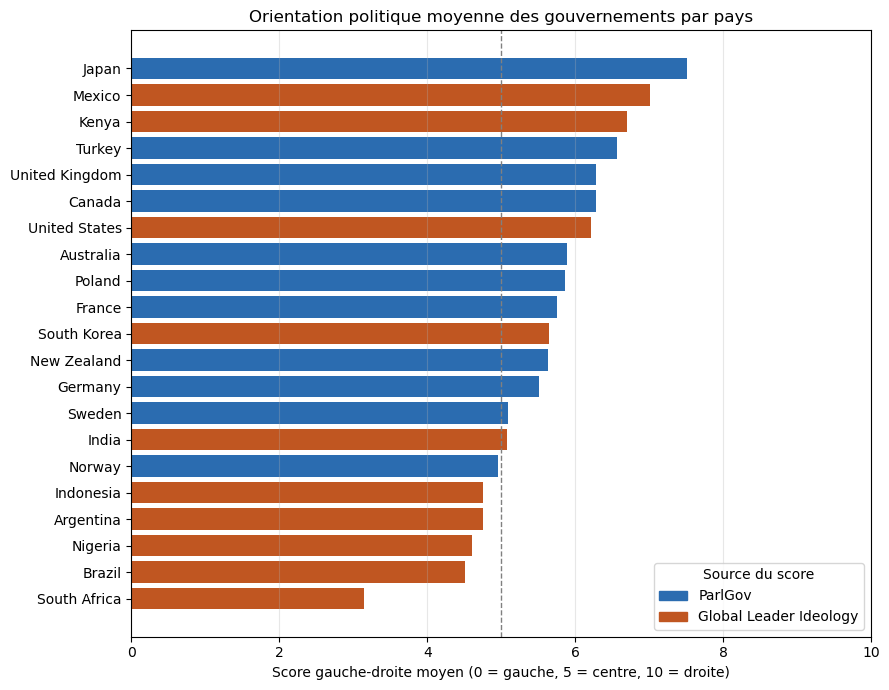

In [69]:
# --- 1. Classement des pays selon leur orientation moyenne ---
colors = {'ParlGov': '#2b6cb0', 'Global Leader Ideology': '#c05621'}
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(country_pol.index, country_pol['left_right_moyen'],
        color=country_pol['source'].map(colors))
ax.axvline(5, color='grey', linestyle='--', linewidth=1)
ax.set_xlim(0, 10)
ax.set_xlabel("Score gauche-droite moyen (0 = gauche, 5 = centre, 10 = droite)")
ax.set_title("Orientation politique moyenne des gouvernements par pays")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), title="Source du score", loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

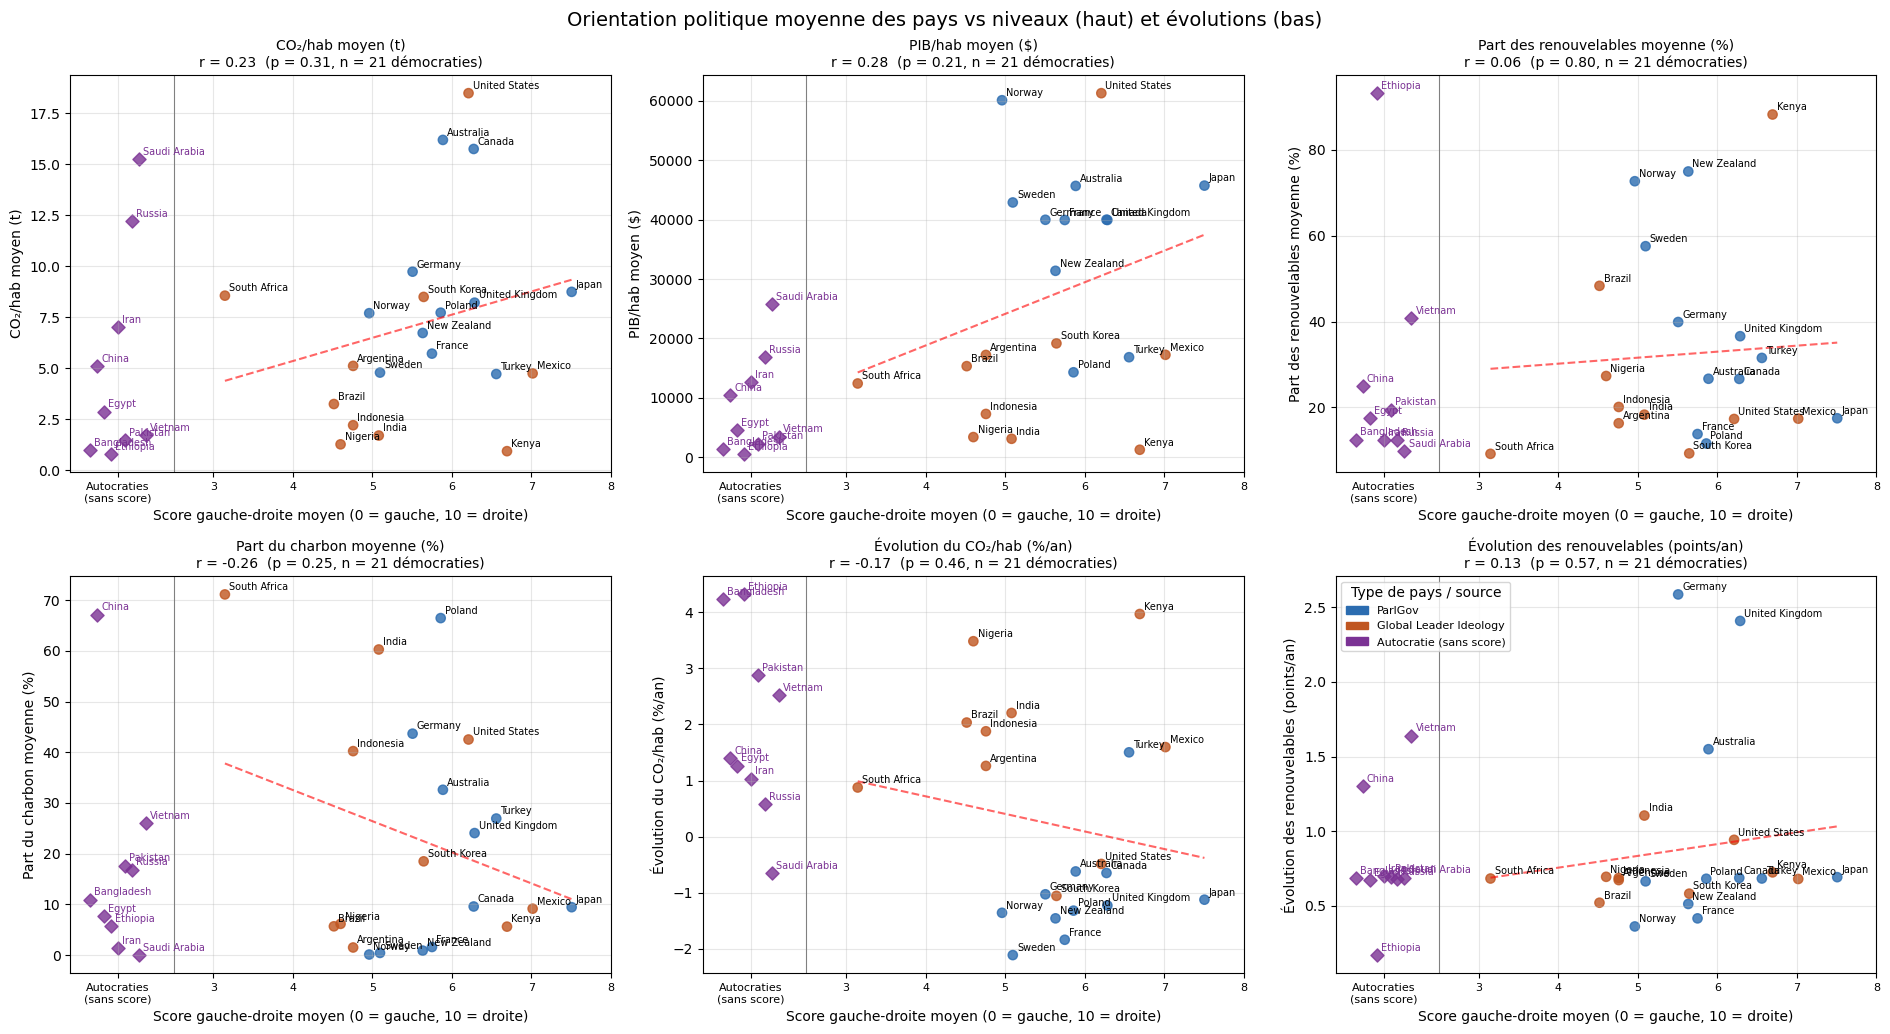

In [70]:
# --- 2 et 3. Orientation moyenne vs autres variables (une ligne = niveaux, une ligne = évolutions) ---
# Les autocraties n'ont pas de score gauche-droite : elles sont placées dans une colonne à part (à gauche),
# et ne sont PAS prises en compte dans la droite de régression ni dans r.
colors = {'ParlGov': '#2b6cb0', 'Global Leader Ideology': '#c05621', 'Autocratie (sans score)': '#7b3294'}
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
X_AUT = 1.8                                                   # position de la colonne « autocraties »
x_aut = X_AUT + np.linspace(-0.35, 0.35, len(country_aut))    # léger étalement pour lire les noms

panels = [
    ('co2_per_capita', "CO₂/hab moyen (t)"),
    ('gdp_per_capita_usd', "PIB/hab moyen ($)"),
    ('share_renewables_pct', "Part des renouvelables moyenne (%)"),
    ('share_coal_pct', "Part du charbon moyenne (%)"),
    ('evol_co2_pct_an', "Évolution du CO₂/hab (%/an)"),
    ('evol_renouv_pts_an', "Évolution des renouvelables (points/an)"),
]

fig, axes = plt.subplots(2, 3, figsize=(19, 10.5))
for ax, (col, label) in zip(axes.flatten(), panels):
    # Démocraties (avec score)
    d = country_pol[['left_right_moyen', col, 'source']].dropna()
    ax.scatter(d['left_right_moyen'], d[col], c=d['source'].map(colors), s=45, alpha=0.8)
    for country, row in d.iterrows():
        ax.annotate(country, (row['left_right_moyen'], row[col]), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')

    # Autocraties (sans score), colonne à part
    ax.scatter(x_aut, country_aut[col], color=colors['Autocratie (sans score)'], s=45, alpha=0.8, marker='D')
    for x, (country, val) in zip(x_aut, country_aut[col].items()):
        ax.annotate(country, (x, val), fontsize=7, xytext=(3, 3), textcoords='offset points',
                    color=colors['Autocratie (sans score)'])
    ax.axvline(2.5, color='grey', linewidth=0.8)

    # Droite de régression + corrélation de Pearson (démocraties uniquement)
    slope, intercept = np.polyfit(d['left_right_moyen'], d[col], 1)
    xs = np.linspace(d['left_right_moyen'].min(), d['left_right_moyen'].max(), 50)
    ax.plot(xs, slope * xs + intercept, 'r--', alpha=0.6)
    r, p = pearsonr(d['left_right_moyen'], d[col])
    ax.set_title(f"{label}\nr = {r:.2f}  (p = {p:.2f}, n = {len(d)} démocraties)", fontsize=10)

    ax.set_xlim(1.2, 8)
    ax.set_xticks([X_AUT, 3, 4, 5, 6, 7, 8])
    ax.set_xticklabels(['Autocraties\n(sans score)', '3', '4', '5', '6', '7', '8'], fontsize=8)
    ax.set_xlabel("Score gauche-droite moyen (0 = gauche, 10 = droite)")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[1, 2].legend(handles, colors.keys(), title="Type de pays / source", fontsize=8)
fig.suptitle("Orientation politique moyenne des pays vs niveaux (haut) et évolutions (bas)", fontsize=14)
plt.tight_layout()
plt.show()

**Lecture :**
- **r** (corrélation de Pearson, entre -1 et 1) : positif = les pays plus à droite ont en moyenne des valeurs plus élevées ; négatif = plus faibles ; proche de 0 = pas de lien linéaire.
- **p** : probabilité d'observer une corrélation au moins aussi forte par hasard s'il n'y avait aucun lien. Avec seulement ~21 pays, on ne considère un lien comme notable que si p < 0.05 ; au-delà, l'écart peut venir du hasard.
- Regarder les **noms des pays** : une corrélation peut être tirée par 1 ou 2 pays extrêmes (ex. un gros producteur de pétrole), ce qui la rend fragile.
- La ligne du bas (évolutions) est la plus proche de la question du modèle sur la variation : si aucun lien n'y apparaît, c'est cohérent avec le fait que les variables politiques n'améliorent pas ce modèle.